#**유통 판매량 예측 및 재고 최적화**
## **단계1 : 데이터 탐색 및 가설 도출**

# **0.미션**

* 예측해야 할 핵심상품 역할 분담
    * 핵심상품 별로, 데이터 탐색, 가설수립, 데이터셋 구성
    * 1인당 1~2개 정도를 분담하여 개별 과제 수행
    * 팀 미팅을 통해 진행 사항 공유 및 취합

* 데이터 탐색 및 가설 도출
    * 주어진 데이터에 대해 대상 매장, 대상 상품의 그래프 그리고 시계열 패턴을 찾기
    * 찾은 패턴을 기반으로 가설 도출

* 대상 상품(핵심 상품)

| Product_ID|Product_Code|SubCategory|Category|LeadTime|Price|
|----|----|----|----|----|----|
|3|DB001|Beverage|Drink|2|8|
|12|GA001|Milk|Food|3|6|
|42|FM001|Agricultural products|Grocery|3|5|


# **1.환경설정**

* 세부 요구사항
    * 구글콜랩
        * 구글 드라이브 바로 밑에 project 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 라이브러리 로딩
        * 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### **(1) 경로 설정**

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/project/'

### **(2) 라이브러리 설치 및 불러오기**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import *
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

### **(3) 데이터 불러오기**

#### 1) 데이터로딩

In [ ]:
path = '/content/drive/MyDrive/project6/'
oil_price = pd.read_csv(path + 'train/oil_price_train.csv')
orders = pd.read_csv(path + 'train/orders_train.csv')
sales = pd.read_csv(path + 'train/sales_train.csv')
products = pd.read_csv(path + 'train/products.csv')
stores = pd.read_csv(path + 'train/stores.csv')

sales['Date'] = pd.to_datetime(sales['Date'] )
oil_price['Date'] = pd.to_datetime(oil_price['Date'] )
orders['Date'] = pd.to_datetime(orders['Date'] )

#### 2) 기본 정보 조회

In [ ]:
orders.head(10)

,Date,Store_ID,CustomerCount
0,2014-01-01,25,840
1,2014-01-01,36,487
2,2014-01-02,1,1875
3,2014-01-02,2,2122
4,2014-01-02,3,3350
5,2014-01-02,4,1661
6,2014-01-02,5,1807
7,2014-01-02,6,2051
8,2014-01-02,7,1836
9,2014-01-02,8,3049


In [ ]:
oil_price.head(10)

,Date,WTI_Price
0,2014-01-01,NaN
1,2014-01-02,95.14
2,2014-01-03,93.66
3,2014-01-06,93.12
4,2014-01-07,93.31
5,2014-01-08,91.90
6,2014-01-09,91.36
7,2014-01-10,92.39
8,2014-01-13,91.45
9,2014-01-14,92.15


In [ ]:
products.head()

,Product_ID,Product_Code,SubCategory,Category,LeadTime,Price
0,20,HG001,Gardening Tools,Household Goods,2,50
1,27,HH001,Home Appliances,Household Goods,2,150
2,16,HK001,Kitchen,Household Goods,2,23
3,15,HK002,Kitchen,Household Goods,2,41
4,32,GS001,Seafood,Grocery,3,34


In [ ]:
sales

,Date,Store_ID,Qty,Product_ID
0,2014-01-01,1,0.000,3
1,2014-01-01,1,0.000,5
2,2014-01-01,1,0.000,7
3,2014-01-01,1,0.000,8
4,2014-01-01,1,0.000,10
...,...,...,...,...
934270,2017-02-28,54,24.000,38
934271,2017-02-28,54,49.222,24
934272,2017-02-28,54,12.000,27
934273,2017-02-28,54,59.000,29


In [ ]:
stores.head()

,Store_ID,City,State,Store_Type
0,1,Saint Paul,\tMinnesota,4
1,2,Saint Paul,\tMinnesota,4
2,3,Saint Paul,\tMinnesota,4
3,4,Saint Paul,\tMinnesota,4
4,5,Oklahoma City,Oklahoma,4


In [ ]:
df = pd.merge(sales, stores, how = 'inner', on = 'Store_ID')
df = pd.merge(df, products, how = 'inner', on = 'Product_ID')
df = pd.merge(df, oil_price, how = 'left', on = 'Date')
df = pd.merge(df, orders, how = 'inner', on = ['Date', 'Store_ID'])
df.head()

,Date,Store_ID,Qty,Product_ID,City,State,Store_Type,Product_Code,SubCategory,Category,LeadTime,Price,WTI_Price,CustomerCount
0,2014-01-01,25,1415.000,3,Olympia,Washington,4,DB001,Beverage,Drink,2,8,NaN,840
1,2014-01-01,25,186.452,5,Olympia,Washington,4,FB001,BAKERY,Food,2,6,NaN,840
2,2014-01-01,25,232.000,7,Olympia,Washington,4,HC001,Cleaning,Household Goods,2,15,NaN,840
3,2014-01-01,25,358.000,8,Olympia,Washington,4,FM001,Yogurt,Food,2,4,NaN,840
4,2014-01-01,25,64.000,10,Olympia,Washington,4,GE001,EGGS,Grocery,2,5,NaN,840


In [ ]:
df = df.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
df.isna().sum()

,0
Date,0
Store_ID,0
Qty,0
Product_ID,0
City,0
State,0
Store_Type,0
Product_Code,0
SubCategory,0
Category,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864516 entries, 0 to 864515
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           864516 non-null  datetime64[ns]
 1   Store_ID       864516 non-null  int64         
 2   Qty            864516 non-null  float64       
 3   Product_ID     864516 non-null  int64         
 4   City           864516 non-null  object        
 5   State          864516 non-null  object        
 6   Store_Type     864516 non-null  int64         
 7   Product_Code   864516 non-null  object        
 8   SubCategory    864516 non-null  object        
 9   Category       864516 non-null  object        
 10  LeadTime       864516 non-null  int64         
 11  Price          864516 non-null  int64         
 12  WTI_Price      864516 non-null  float64       
 13  CustomerCount  864516 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(5

In [ ]:
df.set_index('Date', inplace=True)

In [ ]:
df = df[df.index.year != 2017]
df.tail()

,Store_ID,Qty,Product_ID,City,State,Store_Type,Product_Code,SubCategory,Category,LeadTime,Price,WTI_Price,CustomerCount
Date,,,,,,,,,,,,,
2016-12-31,54,277.000000,38,LA,\tCalifornia,3,DA001,Wine,Drink,2,12,53.065373,1647
2016-12-31,54,61.119003,24,LA,\tCalifornia,3,GM001,Meats,Grocery,3,17,53.064509,1647
2016-12-31,54,10.000000,27,LA,\tCalifornia,3,HH001,Home Appliances,Household Goods,2,150,53.063644,1647
2016-12-31,54,52.000000,29,LA,\tCalifornia,3,FP001,Prepared,Food,2,18,53.062780,1647
2016-12-31,54,2.000000,32,LA,\tCalifornia,3,GS001,Seafood,Grocery,3,34,53.061915,1647


In [ ]:
tdf = df.loc[(df['Store_ID'] == 44) & (df['Product_ID']==42)]
tdf.head(10)

,Store_ID,Qty,Product_ID,City,State,Store_Type,Product_Code,SubCategory,Category,LeadTime,Price,WTI_Price,CustomerCount
Date,,,,,,,,,,,,,
2014-01-02,44,76.0,42,Saint Paul,\tMinnesota,1,FM001,Agricultural products,Grocery,2,5,95.140000,4422
2014-01-03,44,74.0,42,Saint Paul,\tMinnesota,1,FM001,Agricultural products,Grocery,2,5,93.660000,4167
2014-01-04,44,78.0,42,Saint Paul,\tMinnesota,1,FM001,Agricultural products,Grocery,2,5,93.436815,5341
2014-01-05,44,88.0,42,Saint Paul,\tMinnesota,1,FM001,Agricultural products,Grocery,2,5,93.167006,5123
2014-01-06,44,65.0,42,Saint Paul,\tMinnesota,1,FM001,Agricultural products,Grocery,2,5,93.120000,3917
2014-01-07,44,78.0,42,Saint Paul,\tMinnesota,1,FM001,Agricultural products,Grocery,2,5,93.310000,3663
2014-01-08,44,73.0,42,Saint Paul,\tMinnesota,1,FM001,Agricultural products,Grocery,2,5,91.900000,4254
2014-01-09,44,78.0,42,Saint Paul,\tMinnesota,1,FM001,Agricultural products,Grocery,2,5,91.360000,3723
2014-01-10,44,96.0,42,Saint Paul,\tMinnesota,1,FM001,Agricultural products,Grocery,2,5,92.390000,4010


# **2.데이터 탐색**

* 시계열 패턴을 찾아보기 위한 그래프를 그려 봅시다.

## **(1) 시계열 패턴 찾아보기1**

* 다음 항목은 패턴을 찾기 위한 예제 문항 입니다. 참조하여 시계열 패턴을 찾아 봅시다.
    * 대상 매장(44), 대상 상품(3,12,42)의 판매량 추이
    * 대상 상품의 동일 카테고리의 상품별 판매량 추이
    * 휘발유 가격과 상품 판매량 추이 비교
    * 방문 고객수와 상품 판매량 추이 비교
    * 그외...

### 1) 대상 매장(44), 대상 상품의 판매량 추이

#####1) 대상 매장(44), 	Beverage **products의** 판매량 추이

In [ ]:
id=44
order_44=orders.loc[orders['Store_ID'] == id]
drink=products.loc[products['SubCategory'] == 'Beverage']
sales_44=sales.loc[(sales['Store_ID'] == id)&(sales['Product_ID'] == 3)]
sales_44.head(20)
t1=pd.merge(order_44,sales_44,how='inner')
t2=pd.merge(t1,order_44,how='inner')
total=pd.merge(t2,oil_price,how='outer')
total.drop(columns=['Store_ID','Product_ID'],inplace=True)
total['day']=total['Date'].dt.weekday
total['month']=total['Date'].dt.month
total['oil_range']=pd.cut(total['WTI_Price'],bins=[0,30,40,50,60,70,80,90,100,110],labels=['0~30','31~40','41~50','51~60','61~70','71~80','81~90','91~100','101~110'])
total['oil_range'] = total['oil_range'].fillna(method='bfill')
total['WTI_Price'] = total['WTI_Price'].interpolate(method='linear')
total['CustomerCount']=total['CustomerCount'].interpolate(method='linear')
total['Qty']=total['Qty'].interpolate(method='linear')
print(len(total))
#total.drop(index=[total['Qty'].argmax(),total['Qty'].argmax()-1],axis=0,inplace=True)
print(len(total))
#total.replace({'day':{0:'mon',1:'tue',2:'wen',3:'thu',4:'fri',5:'sat',6:'sun'}},inplace=True)
total.head(20)

1152
1152


,Date,CustomerCount,Qty,WTI_Price,day,month,oil_range
0,2014-01-01,NaN,NaN,NaN,2,1,91~100
1,2014-01-02,4422.0,9853.0,95.140000,3,1,91~100
2,2014-01-03,4167.0,8647.0,93.660000,4,1,91~100
3,2014-01-04,5341.0,15153.0,93.480000,5,1,91~100
4,2014-01-05,5123.0,15606.0,93.300000,6,1,91~100
5,2014-01-06,3917.0,7900.0,93.120000,0,1,91~100
6,2014-01-07,3663.0,7188.0,93.310000,1,1,91~100
7,2014-01-08,4254.0,8800.0,91.900000,2,1,91~100
8,2014-01-09,3723.0,6606.0,91.360000,3,1,91~100
9,2014-01-10,4010.0,7051.0,92.390000,4,1,91~100


In [ ]:
# 비교 매장 결합 후 결측치 선형보간
id=4
order_1=orders.loc[orders['Store_ID'] == id]
drink=products.loc[products['SubCategory'] == 'Beverage']
sales_1=sales.loc[(sales['Store_ID'] == id)&(sales['Product_ID'] == 3)]
sales_1.head(20)
t1_1=pd.merge(order_1,sales_1,how='inner')
t2_1=pd.merge(t1_1,order_1,how='inner')
total_1=pd.merge(t2_1,oil_price,how='outer')

total_1.drop(columns=['Store_ID','Product_ID'],inplace=True)
total_1['day']=total['Date'].dt.weekday
total_1['month']=total['Date'].dt.month
total_1['oil_range']=pd.cut(total['WTI_Price'],bins=[0,30,40,50,60,70,80,90,100,110],labels=['0~30','31~40','41~50','51~60','61~70','71~80','81~90','91~100','101~110'])
total_1['oil_range'] = total_1['oil_range'].fillna(method='bfill')
total_1['WTI_Price'] = total_1['WTI_Price'].interpolate(method='linear')
total_1['CustomerCount']=total_1['CustomerCount'].interpolate(method='linear')
total_1['Qty']=total_1['Qty'].interpolate(method='linear')
print(len(total_1))
#total.drop(index=[total['Qty'].argmax(),total['Qty'].argmax()-1],axis=0,inplace=True)
print(len(total_1))

#total.replace({'day':{0:'mon',1:'tue',2:'wen',3:'thu',4:'fri',5:'sat',6:'sun'}},inplace=True)
total_1.head(20)

1151
1151


,Date,CustomerCount,Qty,WTI_Price,day,month,oil_range
0,2014-01-01,NaN,NaN,NaN,2,1,91~100
1,2014-01-02,1661.0,3231.0,95.140000,3,1,91~100
2,2014-01-03,1534.0,2859.0,93.660000,4,1,91~100
3,2014-01-04,1816.0,3626.0,93.480000,5,1,91~100
4,2014-01-05,1954.0,4469.0,93.300000,6,1,91~100
5,2014-01-06,1331.0,2174.0,93.120000,0,1,91~100
6,2014-01-07,1333.0,1927.0,93.310000,1,1,91~100
7,2014-01-08,1502.0,2186.0,91.900000,2,1,91~100
8,2014-01-09,1337.0,1928.0,91.360000,3,1,91~100
9,2014-01-10,1443.0,2060.0,92.390000,4,1,91~100


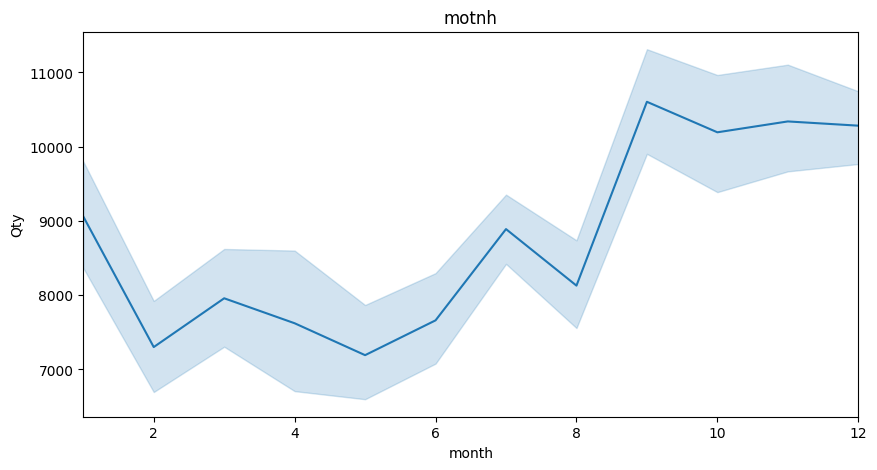

0.24121053541242835


In [ ]:
#월별 수요량
plt.figure(figsize=(10,5))
sns.lineplot(data=total,x='month',y='Qty')
plt.xlim(1,12)
plt.title('month')
plt.show()
print(total['month'].corr(total['Qty']))

#####2) 대상 매장(44), 	Milk **products의** 판매량 추이

In [ ]:
core_products = [3, 12, 42]
sales_ = sales[sales['Store_ID'] == 44]
sales_ = sales_[sales_['Product_ID'].isin(core_products)]

sales_daily = sales_.groupby(['Date', 'Product_ID'])['Qty'].sum().reset_index()

sales_daily = pd.merge(sales_daily, oil_price, on='Date', how='left')

sales_daily['WTI_Price'] = sales_daily.groupby('Product_ID')['WTI_Price'].fillna(method='ffill')

orders_44 = orders[orders['Store_ID'] == 44]
sales_daily = pd.merge(sales_daily, orders_44[['Date', 'Store_ID', 'CustomerCount']], on='Date', how='left')

sales_daily = pd.merge(sales_daily, products[['Product_ID', 'Category']], on='Product_ID', how='left')

sales_daily = sales_daily.drop_duplicates(subset=['Date', 'Product_ID', 'Store_ID'])

sales_daily['CustomerCount'] = sales_daily['CustomerCount'].fillna(method='ffill')

sales_daily['Qty'] = sales_daily['Qty'].fillna(method='ffill')

sales_daily


,Date,Product_ID,Qty,WTI_Price,Store_ID,CustomerCount,Category
0,2014-01-01,3,0.0,NaN,NaN,NaN,Drink
1,2014-01-01,12,0.0,NaN,NaN,NaN,Food
2,2014-01-01,42,51.0,NaN,NaN,NaN,Grocery
3,2014-01-02,3,9853.0,95.14,44.0,4422.0,Drink
4,2014-01-02,12,9647.0,95.14,44.0,4422.0,Food
...,...,...,...,...,...,...,...
3454,2017-02-27,12,10618.0,54.04,44.0,3961.0,Food
3455,2017-02-27,42,78.0,54.04,44.0,3961.0,Grocery
3456,2017-02-28,3,14374.0,54.00,44.0,4589.0,Drink
3457,2017-02-28,12,14400.0,54.00,44.0,4589.0,Food


In [ ]:
sales_12 = sales_daily[sales_daily['Product_ID'] == 12]
sales_12

,Date,Product_ID,Qty,WTI_Price,Store_ID,CustomerCount,Category
1,2014-01-01,12,0.0,NaN,NaN,NaN,Food
4,2014-01-02,12,9647.0,95.14,44.0,4422.0,Food
7,2014-01-03,12,8879.0,93.66,44.0,4167.0,Food
10,2014-01-04,12,14188.0,93.66,44.0,5341.0,Food
13,2014-01-05,12,14490.0,93.66,44.0,5123.0,Food
...,...,...,...,...,...,...,...
3445,2017-02-24,12,10630.0,53.99,44.0,4549.0,Food
3448,2017-02-25,12,12978.0,53.99,44.0,4619.0,Food
3451,2017-02-26,12,10899.0,53.99,44.0,3877.0,Food
3454,2017-02-27,12,10618.0,54.04,44.0,3961.0,Food


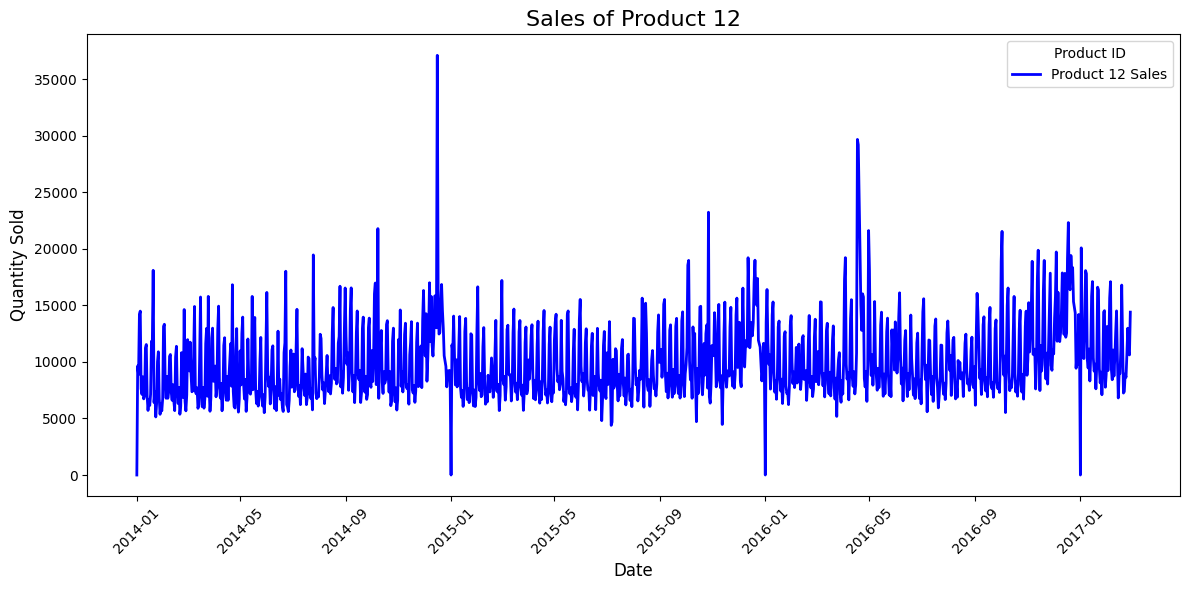

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(sales_12['Date'], sales_12['Qty'], label='Product 12 Sales', color='blue',  linewidth=2)
plt.title('Sales of Product 12', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Quantity Sold', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Product ID')
plt.tight_layout()
plt.show()

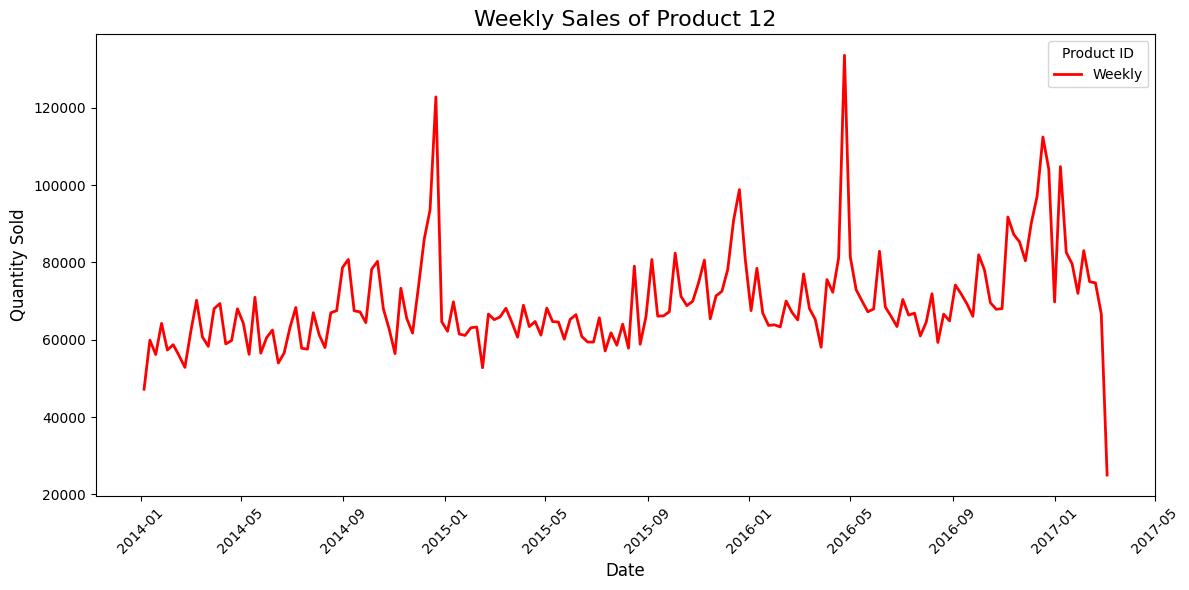

In [ ]:
# 주간 합계 판매량
sales_12_weekly = sales_12.resample('W', on='Date').agg({'Qty': 'sum'}).reset_index()
plt.figure(figsize=(12, 6))
plt.plot(sales_12_weekly['Date'], sales_12_weekly['Qty'], label='Weekly', color='red', linewidth=2)
plt.title('Weekly Sales of Product 12', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Quantity Sold', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Product ID')
plt.tight_layout()
plt.show()

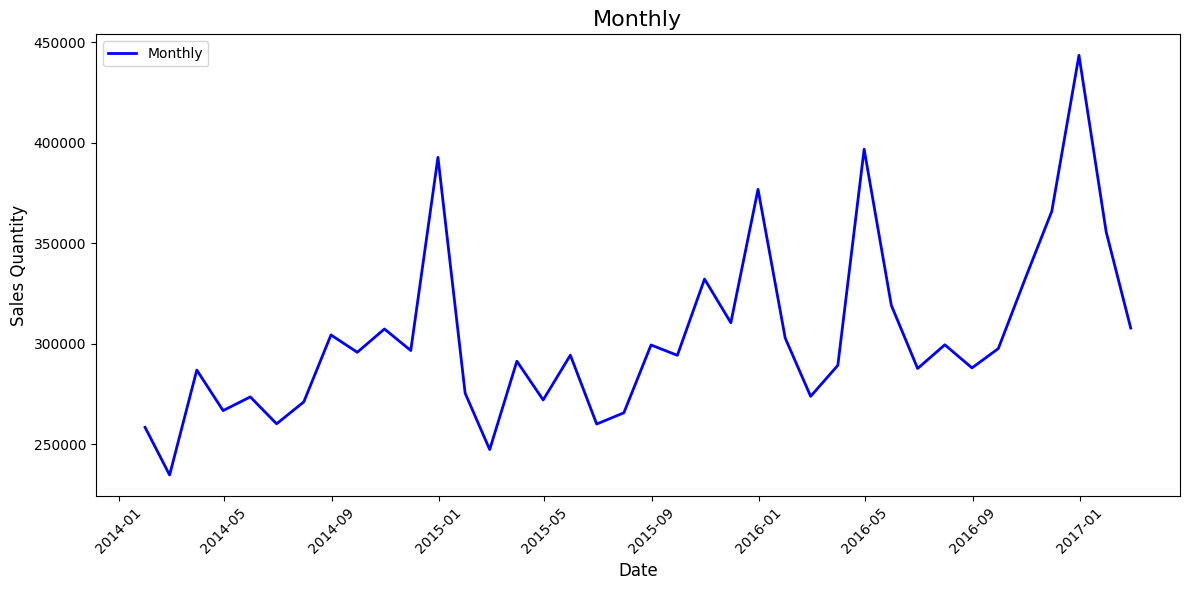

In [ ]:
# 월간 합계 판매량
sales_12_monthly = sales_12.resample('M', on='Date').agg({'Qty': 'sum'}).reset_index()
plt.figure(figsize=(12, 6))
plt.plot(sales_12_monthly['Date'], sales_12_monthly['Qty'], label='Monthly', color='blue', linewidth=2)
plt.title('Monthly', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales Quantity', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#####3) 대상 매장(44), 	Agricultural **products의** 판매량 추이

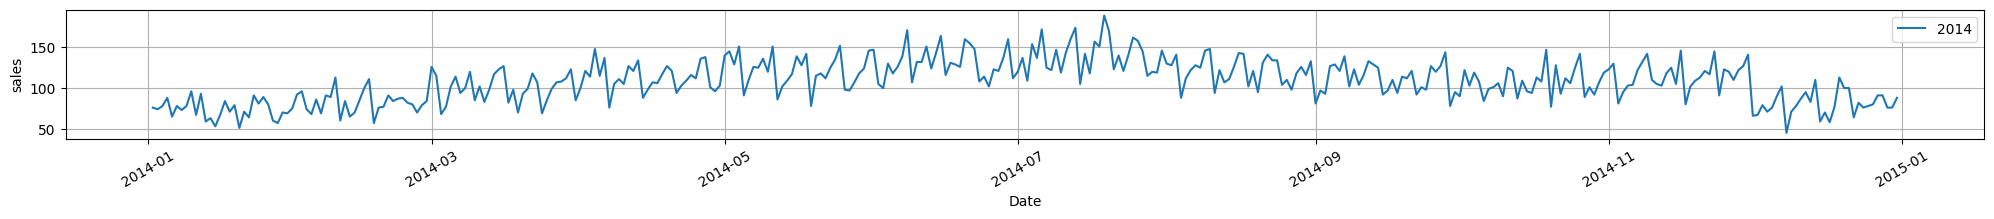

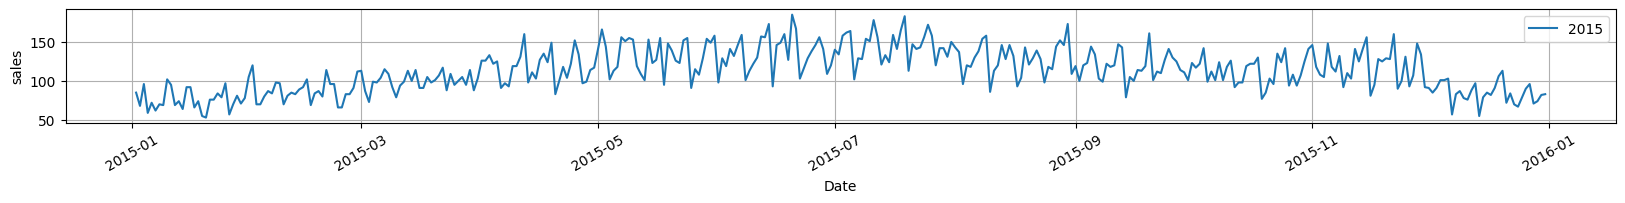

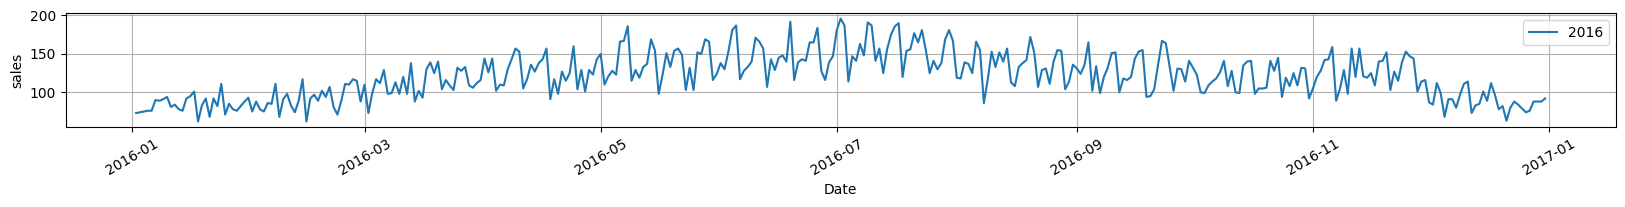

In [ ]:
df_2014 = tdf[tdf.index.year == 2014]
df_2015 = tdf[tdf.index.year == 2015]
df_2016 = tdf[tdf.index.year == 2016]
#연도별 일별 판매량
plt.figure(figsize = (20, 5))
plt.subplot(3,1,1)
plt.tight_layout()
plt.plot(df_2014['Qty'], label='2014')
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()
plt.figure(figsize = (20, 5))
plt.subplot(3,1,2)
plt.plot(df_2015['Qty'], label='2015')
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()
plt.figure(figsize = (20, 5))
plt.subplot(3,1,3)
plt.plot(df_2016['Qty'], label='2016')
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()


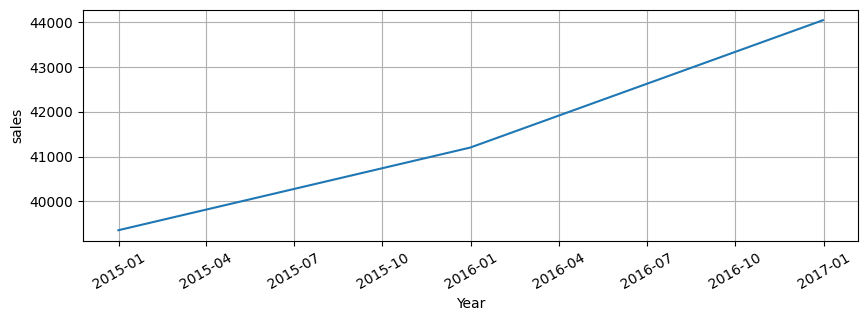

In [ ]:
#연도별 판매량
plt.figure(figsize = (10, 3))
year = tdf['Qty'].resample('Y').sum()
plt.plot(year.index,year.values)
plt.xticks(rotation = 30)
plt.xlabel('Year')
plt.ylabel('sales')
plt.grid()
plt.show()

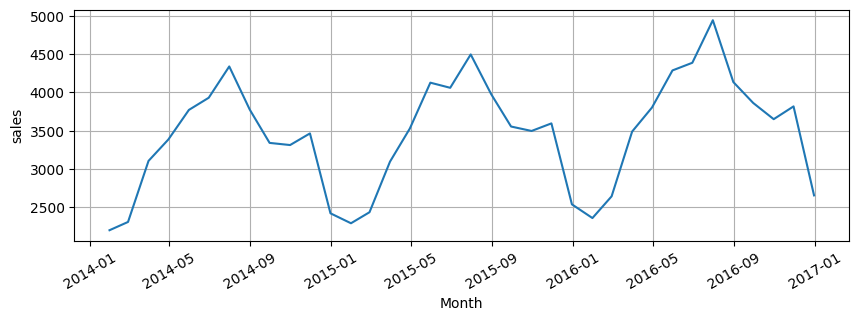

In [ ]:
#월별 판매량
plt.figure(figsize = (10, 3))
mon = tdf['Qty'].resample('M').sum()
plt.plot(mon.index,mon.values)
plt.xticks(rotation = 30)
plt.xlabel('Month')
plt.ylabel('sales')
plt.grid()
plt.show()

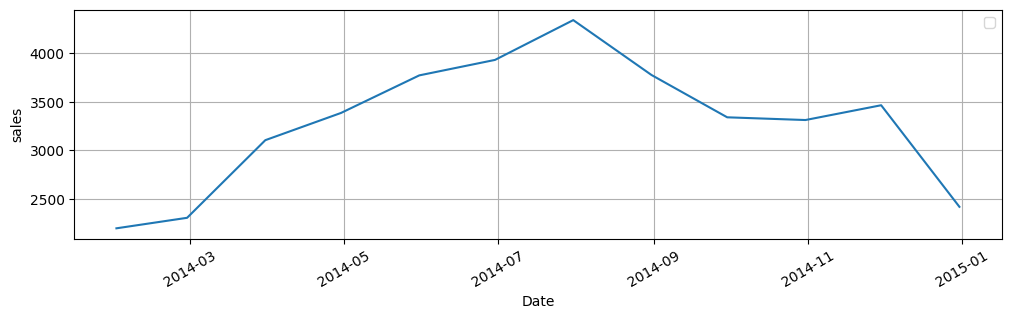

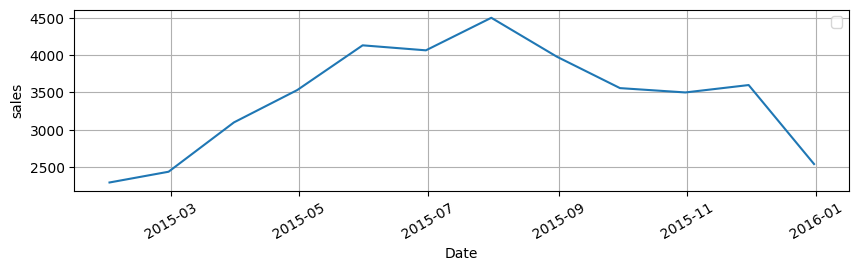

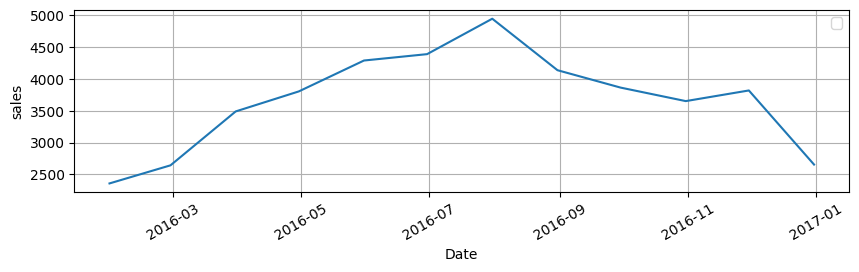

In [ ]:
#연도별 월별 판매량
plt.figure(figsize = (10, 8))
plt.subplot(3,1,1)
plt.tight_layout()
mon_2014 = df_2014['Qty'].resample('M').sum()
plt.plot(mon_2014.index,mon_2014.values)
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

plt.figure(figsize = (10, 8))
plt.subplot(3,1,2)
mon_2015 = df_2015['Qty'].resample('M').sum()
plt.plot(mon_2015.index,mon_2015.values)
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

plt.figure(figsize = (10, 8))
plt.subplot(3,1,3)
mon_2016 = df_2016['Qty'].resample('M').sum()
plt.plot(mon_2016.index,mon_2016.values)
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

In [ ]:
sales_44_grouped = tdf.groupby(tdf.index.to_period('Q'))['Qty'].sum().reset_index()
sales_44_grouped

,Date,Qty
0,2014Q1,7614.0
1,2014Q2,11089.0
2,2014Q3,11457.0
3,2014Q4,9199.0
4,2015Q1,7822.0
5,2015Q2,11718.0
6,2015Q3,12029.0
7,2015Q4,9631.0
8,2016Q1,8491.0
9,2016Q2,12479.0


In [ ]:
# 분기를 float64로 변환하는 함수
def period_to_float(period):
    year = period.year
    quarter = period.quarter
    return year + (quarter - 1) / 4.0

# 분기 데이터 변환
sales_44_grouped['Date'] = sales_44_grouped['Date'].apply(period_to_float)

In [ ]:
sales_44_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    12 non-null     float64
 1   Qty     12 non-null     float64
dtypes: float64(2)
memory usage: 320.0 bytes


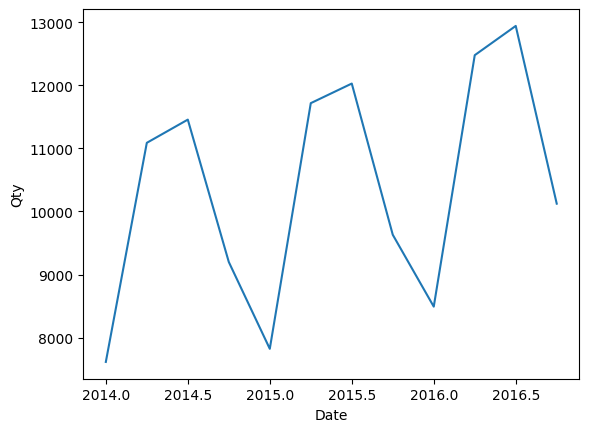

In [ ]:
#분기별 판매량 변화
plt.figure()
sns.lineplot(data=sales_44_grouped,x=sales_44_grouped['Date'], y=sales_44_grouped['Qty'])
plt.show()

### 2) 대상 상품의 동일 카테고리의 상품별 판매량 추이

#####1) 대상 매장(44),Beverage 카테고리의 판매량 추이

In [ ]:
order_38=orders.loc[orders['Store_ID'] == 44]
drink=products.loc[products['Category'] == 'Drink']
sales_38=sales.loc[(sales['Store_ID'] == 44)&(sales['Product_ID'] == 38)]
sales_38.head(20)
t1_38=pd.merge(order_38,sales_38,how='inner')
t2_38=pd.merge(t1_38,order_38,how='inner')
total_38=pd.merge(t2_38,oil_price,how='inner')
#total_13.drop(columns=['Store_ID','Product_ID'],inplace=True)
total_38

,Date,Store_ID,CustomerCount,Qty,Product_ID,WTI_Price
0,2014-01-02,44,4422,289.0,38,95.14
1,2014-01-03,44,4167,333.0,38,93.66
2,2014-01-06,44,3917,183.0,38,93.12
3,2014-01-07,44,3663,155.0,38,93.31
4,2014-01-08,44,4254,192.0,38,91.90
...,...,...,...,...,...,...
814,2017-02-22,44,3834,262.0,38,53.61
815,2017-02-23,44,3955,298.0,38,54.48
816,2017-02-24,44,4549,481.0,38,53.99
817,2017-02-27,44,3961,428.0,38,54.04


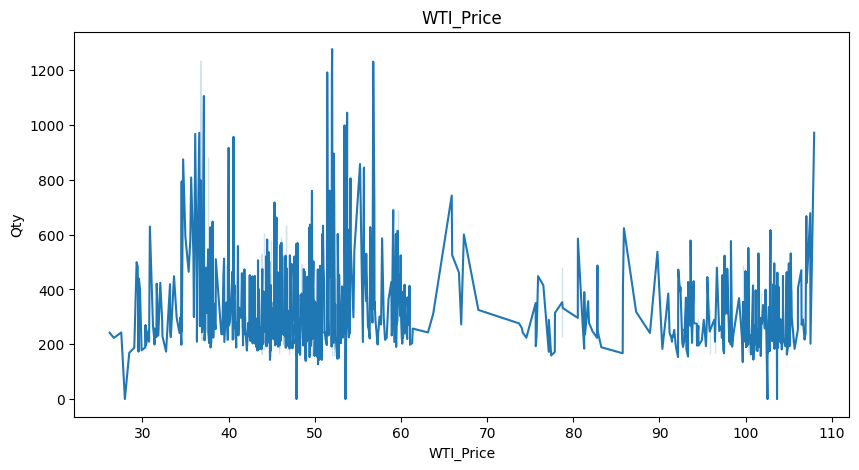

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=total_38,x='WTI_Price',y='Qty')
plt.title('WTI_Price')

plt.show()

#####2) 대상 매장(44), Milk 카테고리의 판매량 추이

In [ ]:
food_products = products[products['Category'] == 'Food']
food_product_subcategories = food_products[['Product_ID', 'SubCategory']]
print(food_product_subcategories)

    Product_ID SubCategory
6           29    Prepared
7           11      Frozen
10           5      BAKERY
11           8      Yogurt
14          12        Milk


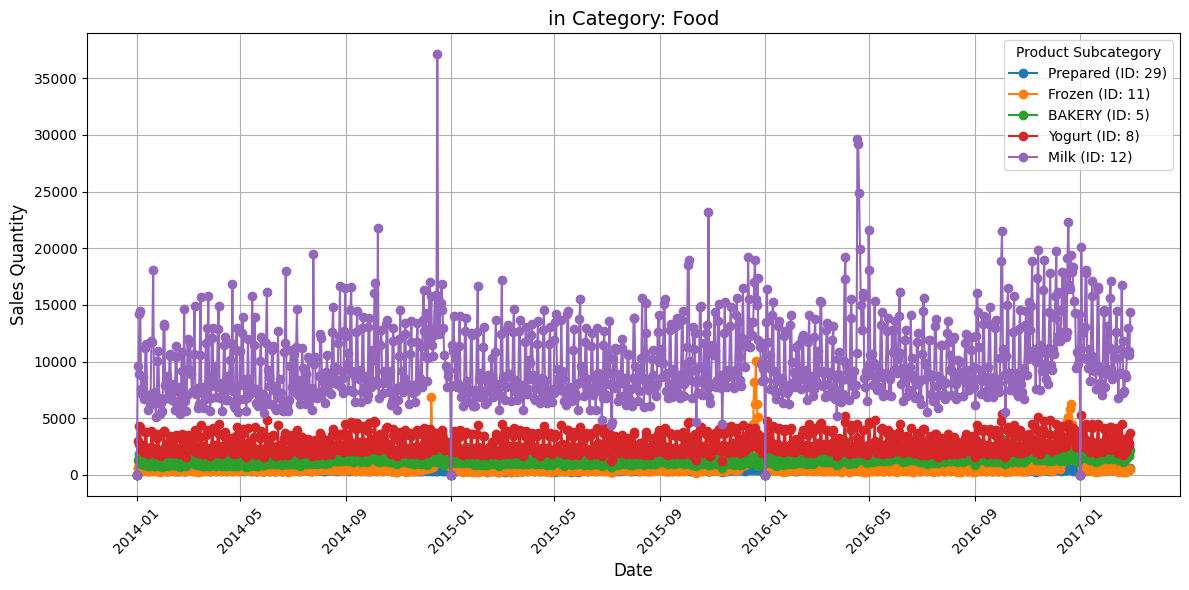

In [ ]:
target_category = products[products['Product_ID'] == 12]['Category'].values[0]
same_category_products = products[products['Category'] == target_category]['Product_ID'].values
sales_same_category = sales[sales['Product_ID'].isin(same_category_products)]
sales_same_category_44 = sales_same_category[sales_same_category['Store_ID'] == 44]
sales_trend_same_category = sales_same_category_44.groupby(['Date', 'Product_ID'])['Qty'].sum().reset_index()
sales_trend_same_category['Date'] = pd.to_datetime(sales_trend_same_category['Date'])
plt.figure(figsize=(12, 6))
for product_id in same_category_products:
    product_sales = sales_trend_same_category[sales_trend_same_category['Product_ID'] == product_id]
    subcategory = products[products['Product_ID'] == product_id]['SubCategory'].values[0]
    plt.plot(product_sales['Date'], product_sales['Qty'], marker='o', label=f'{subcategory} (ID: {product_id})')
plt.title(f'in Category: {target_category}', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales Quantity', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="Product Subcategory", fontsize=10)
plt.tight_layout()
plt.show()

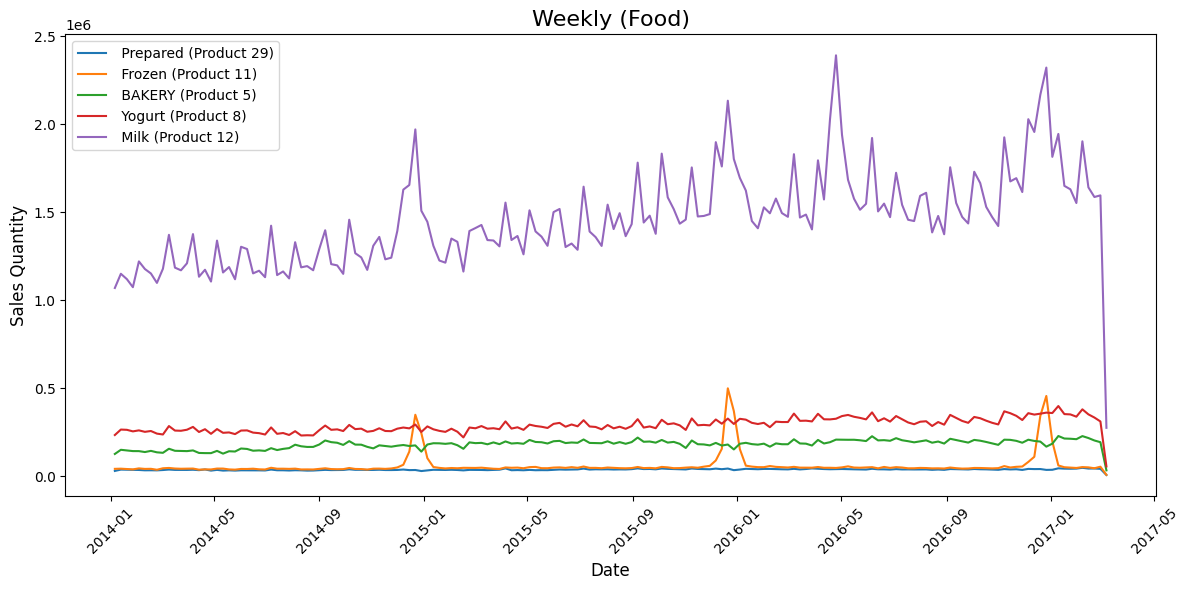

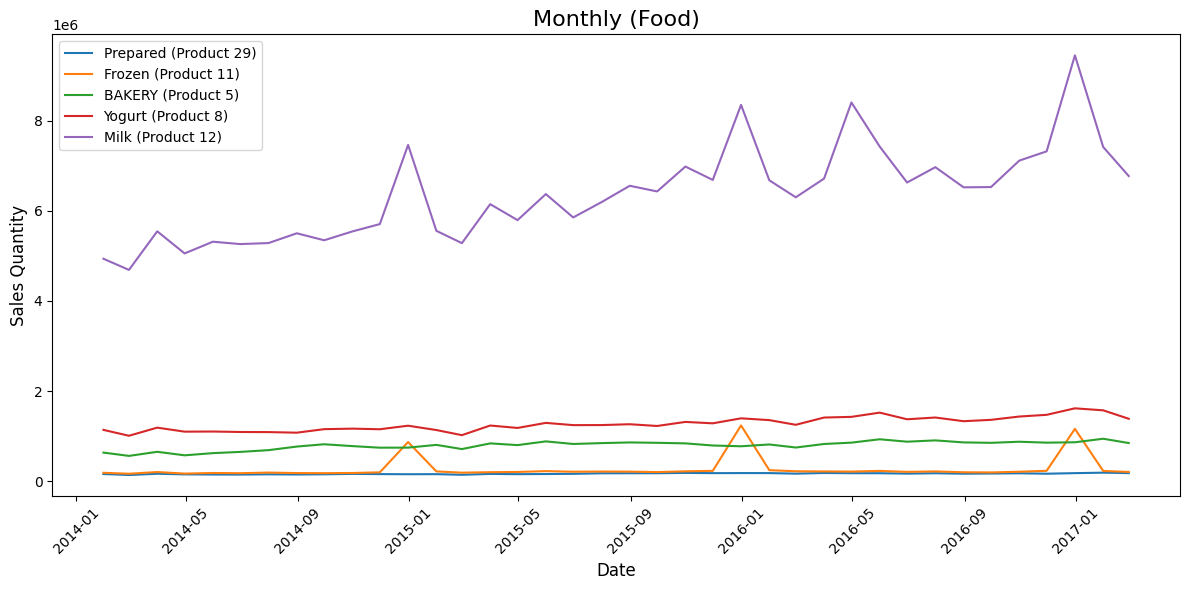

In [ ]:
category = products[products['Product_ID'] == 12]['Category'].iloc[0]
same_category_products = products[products['Category'] == category]['Product_ID'].tolist()
sales_category = sales[sales['Product_ID'].isin(same_category_products)]
sales_category['Date'] = pd.to_datetime(sales_category['Date'])
sales_category_weekly = sales_category.groupby([pd.Grouper(key='Date', freq='W-Mon'), 'Product_ID'])['Qty'].sum().reset_index()
sales_category_monthly = sales_category.groupby([pd.Grouper(key='Date', freq='M'), 'Product_ID'])['Qty'].sum().reset_index()
plt.figure(figsize=(12, 6))
for product in same_category_products:
    product_sales = sales_category_weekly[sales_category_weekly['Product_ID'] == product]
    subcategory = products[products['Product_ID'] == product]['SubCategory'].values[0]
    plt.plot(product_sales['Date'], product_sales['Qty'], label=f' {subcategory} (Product {product})')
plt.title(f'Weekly ({category})', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales Quantity', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for product in same_category_products:
    product_sales = sales_category_monthly[sales_category_monthly['Product_ID'] == product]
    subcategory = products[products['Product_ID'] == product]['SubCategory'].values[0]
    plt.plot(product_sales['Date'], product_sales['Qty'], label=f'{subcategory} (Product {product})')
plt.title(f'Monthly ({category})', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales Quantity', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#####3) 대상 매장(44), Grocery 카테고리의 판매량 추이

In [ ]:
cdf = df.loc[(df['Store_ID'] == 44) & (df['Category']=='Grocery')]
print(cdf['SubCategory'].unique())
egg = cdf.loc[cdf['SubCategory']=='Egg']
meat = cdf.loc[cdf['SubCategory']=='Meats']
agr = cdf.loc[cdf['SubCategory']=='Agricultural products']
seafood = cdf.loc[cdf['SubCategory']=='Seafood']

['EGGS' 'Meats' 'Agricultural products' 'Seafood']


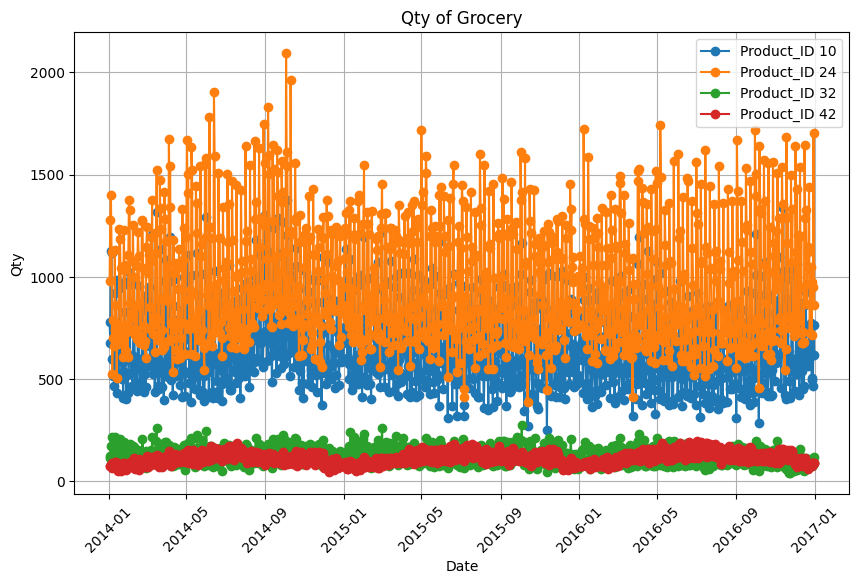

In [ ]:
#Grocery 카테고리의 판매량 비교
tdf2 = cdf.loc[cdf['Product_ID'].isin([10,24,32,42])]
plt.figure(figsize=(10, 6))
for pid in [10,24,32,42]:
    subset = tdf2[tdf2['Product_ID'] == pid]
    plt.plot(subset.index, subset['Qty'], marker='o', label=f'Product_ID {pid}')

plt.title('Qty of Grocery')
plt.xlabel('Date')
plt.ylabel('Qty')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

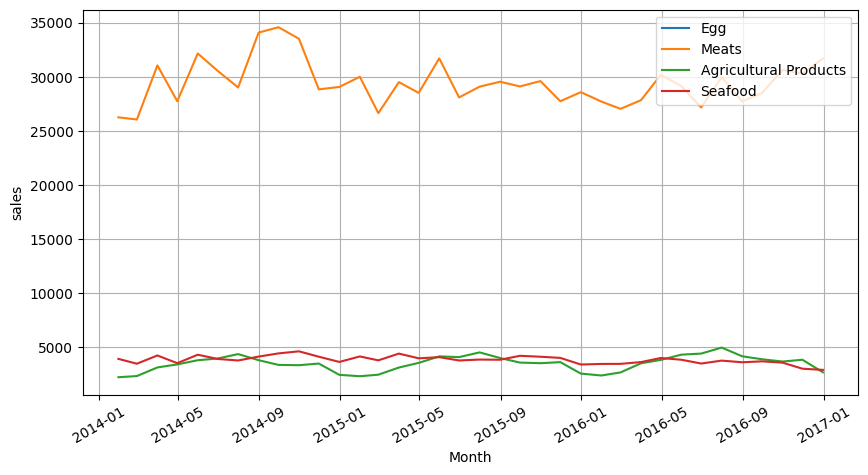

In [ ]:
#전체 월별 카테고리 비교
plt.figure(figsize = (10, 5))
eMon = egg.resample('M')['Qty'].sum()
mMon = meat.resample('M')['Qty'].sum()
aMon = agr.resample('M')['Qty'].sum()
sMon = seafood.resample('M')['Qty'].sum()
plt.plot(eMon.index, eMon.values, label='Egg')
plt.plot(mMon.index, mMon.values, label='Meats')
plt.plot(aMon.index, aMon.values, label='Agricultural Products')
plt.plot(sMon.index, sMon.values, label='Seafood')
mday = meat.resample('D').sum()
plt.xticks(rotation = 30)
plt.xlabel('Month')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

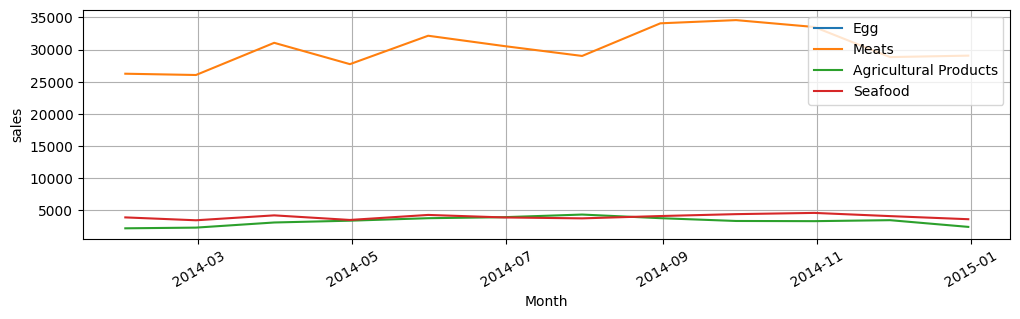

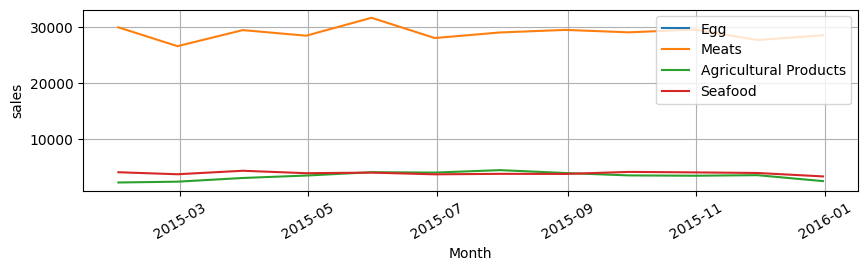

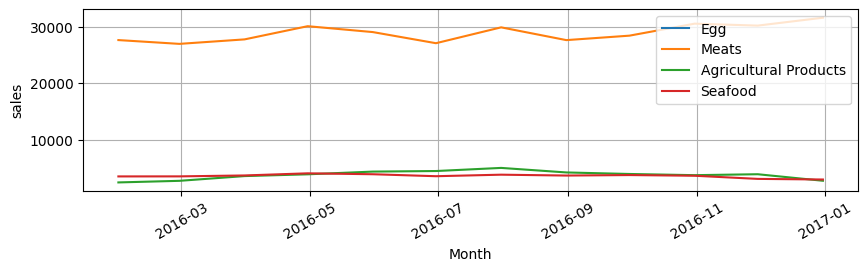

In [ ]:
#연도별 월별 카테고리 비교
egg_2014 = egg[egg.index.year == 2014]
egg_2015 = egg[egg.index.year == 2015]
egg_2016 = egg[egg.index.year == 2016]

meat_2014 = meat[meat.index.year == 2014]
meat_2015 = meat[meat.index.year == 2015]
meat_2016 = meat[meat.index.year == 2016]

agr_2014 = agr[agr.index.year == 2014]
agr_2015 = agr[agr.index.year == 2015]
agr_2016 = agr[agr.index.year == 2016]

seafood_2014 = seafood[seafood.index.year == 2014]
seafood_2015 = seafood[seafood.index.year == 2015]
seafood_2016 = seafood[seafood.index.year == 2016]

plt.figure(figsize = (10, 8))
plt.subplot(3,1,1)
plt.tight_layout()
eMon_2014 = egg_2014.resample('M')['Qty'].sum()
mMon_2014 = meat_2014.resample('M')['Qty'].sum()
aMon_2014 = agr_2014.resample('M')['Qty'].sum()
sMon_2014 = seafood_2014.resample('M')['Qty'].sum()
plt.plot(eMon_2014.index, eMon_2014.values, label='Egg')
plt.plot(mMon_2014.index, mMon_2014.values, label='Meats')
plt.plot(aMon_2014.index, aMon_2014.values, label='Agricultural Products')
plt.plot(sMon_2014.index, sMon_2014.values, label='Seafood')
plt.xticks(rotation = 30)
plt.xlabel('Month')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

plt.figure(figsize = (10, 8))
plt.subplot(3,1,2)
eMon_2015 = egg_2015.resample('M')['Qty'].sum()
mMon_2015 = meat_2015.resample('M')['Qty'].sum()
aMon_2015 = agr_2015.resample('M')['Qty'].sum()
sMon_2015 = seafood_2015.resample('M')['Qty'].sum()
plt.plot(eMon_2015.index, eMon_2015.values, label='Egg')
plt.plot(mMon_2015.index, mMon_2015.values, label='Meats')
plt.plot(aMon_2015.index, aMon_2015.values, label='Agricultural Products')
plt.plot(sMon_2015.index, sMon_2015.values, label='Seafood')
plt.xticks(rotation = 30)
plt.xlabel('Month')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

plt.figure(figsize = (10, 8))
plt.subplot(3,1,3)
eMon_2016 = egg_2016.resample('M')['Qty'].sum()
mMon_2016 = meat_2016.resample('M')['Qty'].sum()
aMon_2016 = agr_2016.resample('M')['Qty'].sum()
sMon_2016 = seafood_2016.resample('M')['Qty'].sum()
plt.plot(eMon_2016.index, eMon_2016.values, label='Egg')
plt.plot(mMon_2016.index, mMon_2016.values, label='Meats')
plt.plot(aMon_2016.index, aMon_2016.values, label='Agricultural Products')
plt.plot(sMon_2016.index, sMon_2016.values, label='Seafood')
plt.xticks(rotation = 30)
plt.xlabel('Month')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

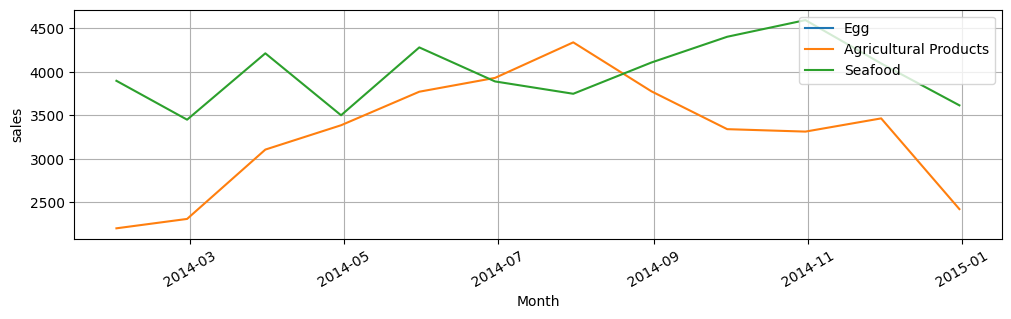

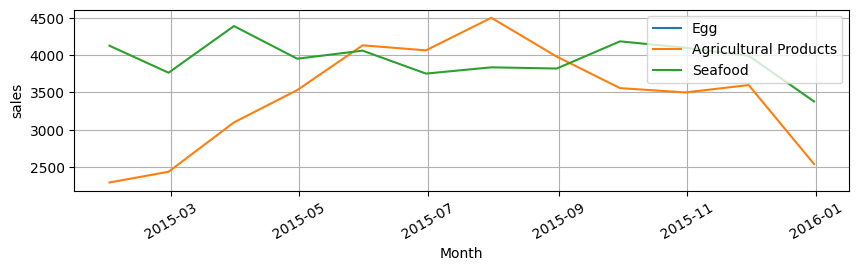

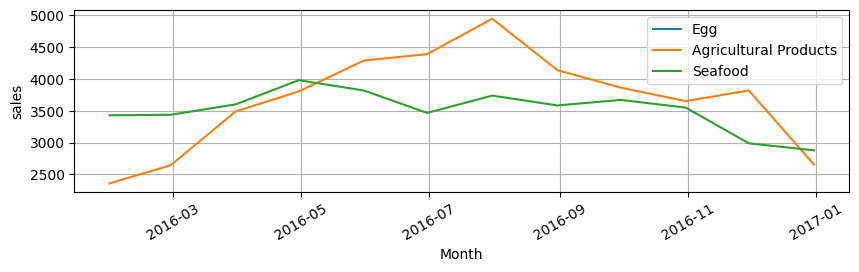

In [ ]:
#연도별 월별 카테고리 비교 -> 고기 빼고
egg_2014 = egg[egg.index.year == 2014]
egg_2015 = egg[egg.index.year == 2015]
egg_2016 = egg[egg.index.year == 2016]

agr_2014 = agr[agr.index.year == 2014]
agr_2015 = agr[agr.index.year == 2015]
agr_2016 = agr[agr.index.year == 2016]

seafood_2014 = seafood[seafood.index.year == 2014]
seafood_2015 = seafood[seafood.index.year == 2015]
seafood_2016 = seafood[seafood.index.year == 2016]

plt.figure(figsize = (10, 8))
plt.subplot(3,1,1)
plt.tight_layout()
eMon_2014 = egg_2014.resample('M')['Qty'].sum()
aMon_2014 = agr_2014.resample('M')['Qty'].sum()
sMon_2014 = seafood_2014.resample('M')['Qty'].sum()
plt.plot(eMon_2014.index, eMon_2014.values, label='Egg')
plt.plot(aMon_2014.index, aMon_2014.values, label='Agricultural Products')
plt.plot(sMon_2014.index, sMon_2014.values, label='Seafood')
plt.xticks(rotation = 30)
plt.xlabel('Month')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

plt.figure(figsize = (10, 8))
plt.subplot(3,1,2)
eMon_2015 = egg_2015.resample('M')['Qty'].sum()
aMon_2015 = agr_2015.resample('M')['Qty'].sum()
sMon_2015 = seafood_2015.resample('M')['Qty'].sum()
plt.plot(eMon_2015.index, eMon_2015.values, label='Egg')
plt.plot(aMon_2015.index, aMon_2015.values, label='Agricultural Products')
plt.plot(sMon_2015.index, sMon_2015.values, label='Seafood')
plt.xticks(rotation = 30)
plt.xlabel('Month')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

plt.figure(figsize = (10, 8))
plt.subplot(3,1,3)
eMon_2016 = egg_2016.resample('M')['Qty'].sum()
aMon_2016 = agr_2016.resample('M')['Qty'].sum()
sMon_2016 = seafood_2016.resample('M')['Qty'].sum()
plt.plot(eMon_2016.index, eMon_2016.values, label='Egg')
plt.plot(aMon_2016.index, aMon_2016.values, label='Agricultural Products')
plt.plot(sMon_2016.index, sMon_2016.values, label='Seafood')
plt.xticks(rotation = 30)
plt.xlabel('Month')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

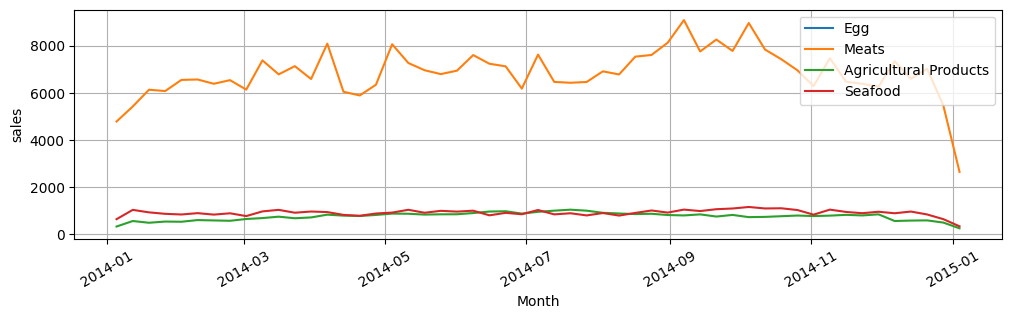

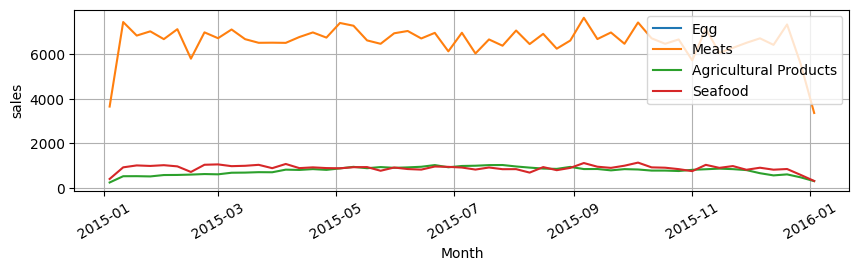

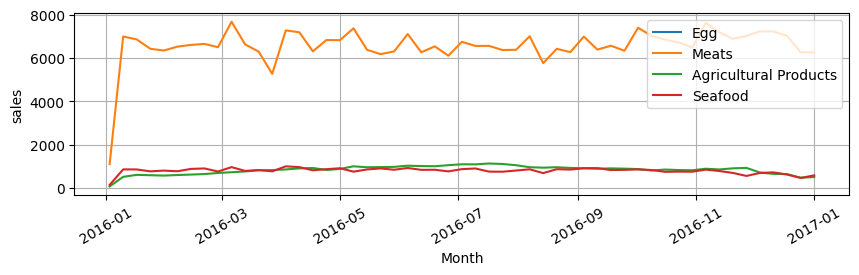

In [ ]:
#연도별 주별 카테고리 비교
egg_2014 = egg[egg.index.year == 2014]
egg_2015 = egg[egg.index.year == 2015]
egg_2016 = egg[egg.index.year == 2016]

meat_2014 = meat[meat.index.year == 2014]
meat_2015 = meat[meat.index.year == 2015]
meat_2016 = meat[meat.index.year == 2016]

agr_2014 = agr[agr.index.year == 2014]
agr_2015 = agr[agr.index.year == 2015]
agr_2016 = agr[agr.index.year == 2016]

seafood_2014 = seafood[seafood.index.year == 2014]
seafood_2015 = seafood[seafood.index.year == 2015]
seafood_2016 = seafood[seafood.index.year == 2016]

plt.figure(figsize = (10, 8))
plt.subplot(3,1,1)
plt.tight_layout()
eMon_2014 = egg_2014.resample('W')['Qty'].sum()
mMon_2014 = meat_2014.resample('W')['Qty'].sum()
aMon_2014 = agr_2014.resample('W')['Qty'].sum()
sMon_2014 = seafood_2014.resample('W')['Qty'].sum()
plt.plot(eMon_2014.index, eMon_2014.values, label='Egg')
plt.plot(mMon_2014.index, mMon_2014.values, label='Meats')
plt.plot(aMon_2014.index, aMon_2014.values, label='Agricultural Products')
plt.plot(sMon_2014.index, sMon_2014.values, label='Seafood')
plt.xticks(rotation = 30)
plt.xlabel('Month')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

plt.figure(figsize = (10, 8))
plt.subplot(3,1,2)
eMon_2015 = egg_2015.resample('W')['Qty'].sum()
mMon_2015 = meat_2015.resample('W')['Qty'].sum()
aMon_2015 = agr_2015.resample('W')['Qty'].sum()
sMon_2015 = seafood_2015.resample('W')['Qty'].sum()
plt.plot(eMon_2015.index, eMon_2015.values, label='Egg')
plt.plot(mMon_2015.index, mMon_2015.values, label='Meats')
plt.plot(aMon_2015.index, aMon_2015.values, label='Agricultural Products')
plt.plot(sMon_2015.index, sMon_2015.values, label='Seafood')
plt.xticks(rotation = 30)
plt.xlabel('Month')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

plt.figure(figsize = (10, 8))
plt.subplot(3,1,3)
eMon_2016 = egg_2016.resample('W')['Qty'].sum()
mMon_2016 = meat_2016.resample('W')['Qty'].sum()
aMon_2016 = agr_2016.resample('W')['Qty'].sum()
sMon_2016 = seafood_2016.resample('W')['Qty'].sum()
plt.plot(eMon_2016.index, eMon_2016.values, label='Egg')
plt.plot(mMon_2016.index, mMon_2016.values, label='Meats')
plt.plot(aMon_2016.index, aMon_2016.values, label='Agricultural Products')
plt.plot(sMon_2016.index, sMon_2016.values, label='Seafood')
plt.xticks(rotation = 30)
plt.xlabel('Month')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

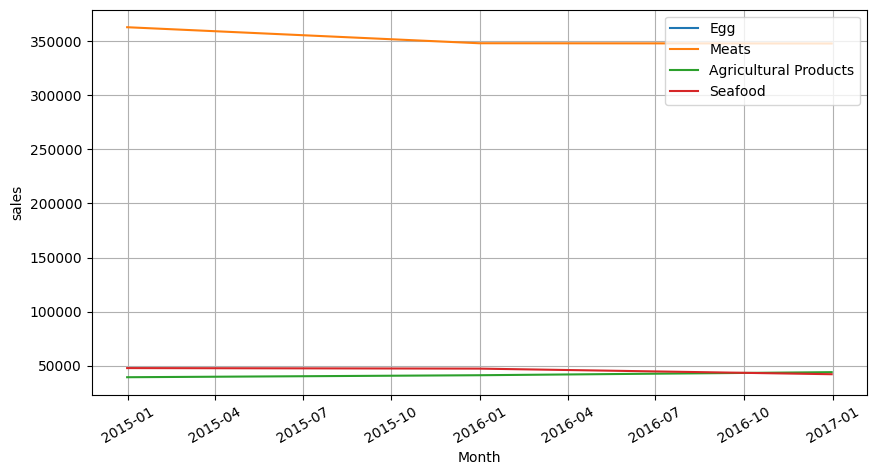

In [ ]:
#연도별 카테고리 비교
plt.figure(figsize = (10, 5))
eYaer = egg.resample('Y')['Qty'].sum()
mYaer = meat.resample('Y')['Qty'].sum()
aYaer = agr.resample('Y')['Qty'].sum()
sYaer = seafood.resample('Y')['Qty'].sum()
plt.plot(eYaer.index, eYaer.values, label='Egg')
plt.plot(mYaer.index, mYaer.values, label='Meats')
plt.plot(aYaer.index, aYaer.values, label='Agricultural Products')
plt.plot(sYaer.index, sYaer.values, label='Seafood')
mday = meat.resample('D').sum()
plt.xticks(rotation = 30)
plt.xlabel('Month')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

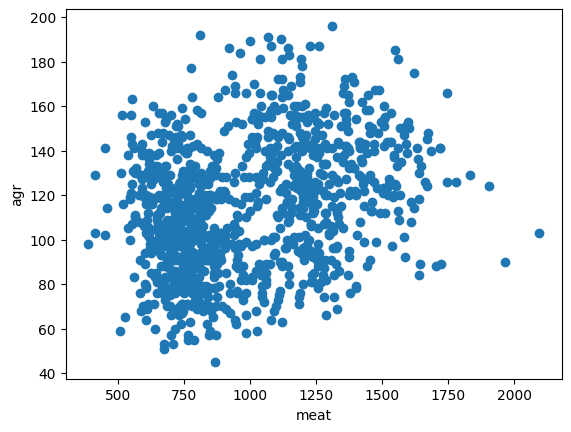

PearsonRResult(statistic=0.3047499668209285, pvalue=8.129431309633259e-25)

In [ ]:
import scipy.stats as spst
plt.scatter(meat['Qty'], agr['Qty'])
plt.xlabel('meat')
plt.ylabel('agr')
plt.show()
spst.pearsonr(meat['Qty'], agr['Qty'])


### 3) 휘발유 가격과 상품 판매량 추이 비교

#####1) 대상 매장(44), Beverage 판매량과 휘발유 가격 추이 비교

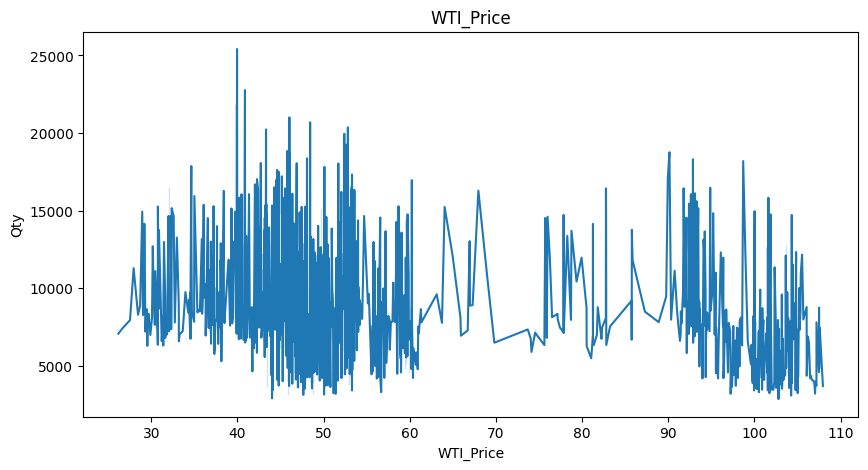

In [ ]:
#유가에 따른 수요 그래프
plt.figure(figsize=(10,5))
sns.lineplot(data=total,x='WTI_Price',y='Qty')
plt
plt.title('WTI_Price')

plt.show()

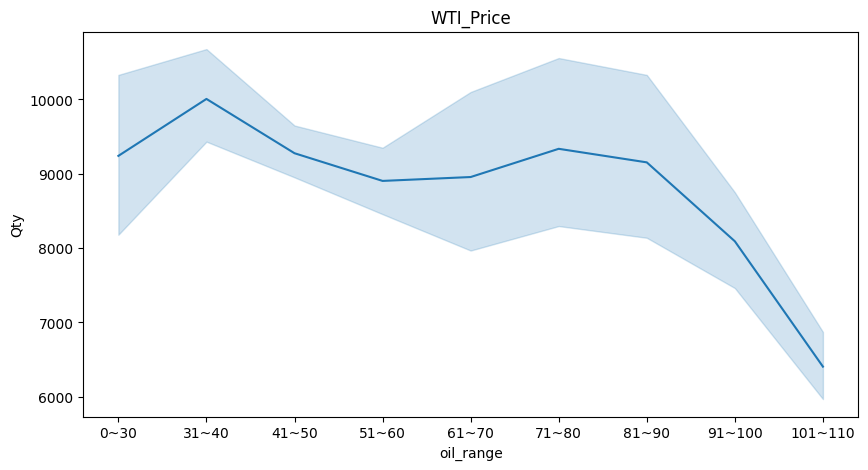

-0.2661932834768389


In [ ]:
#유가를 범주로 잡은후 수요량 그래프
plt.figure(figsize=(10,5))
sns.lineplot(data=total,x='oil_range',y='Qty')

plt.title('WTI_Price')

plt.show()
print(total['WTI_Price'].corr(total['Qty']))

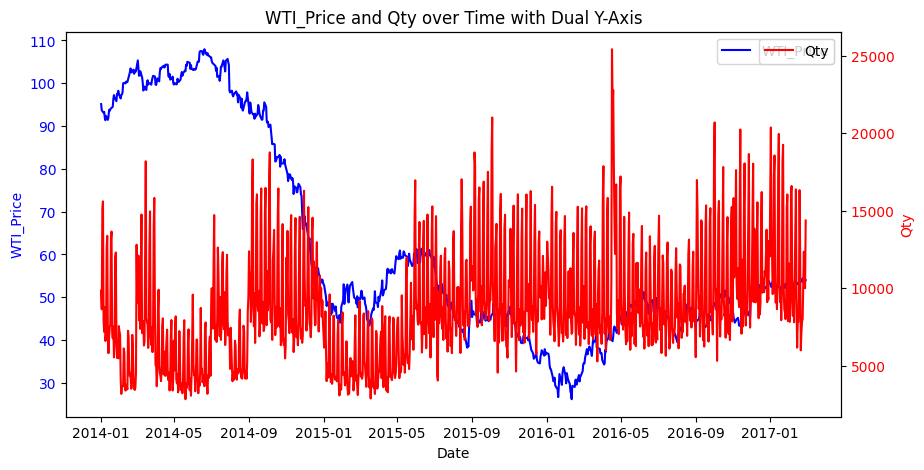

In [ ]:
# 유가에 따른 수요량 그래프 통합 해 비교
# 첫 번째 y축 그래프 (왼쪽)
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.lineplot(data=total, x='Date', y='WTI_Price', ax=ax1, color="b", label="WTI_Price")
ax1.set_ylabel('WTI_Price', color="b")
ax1.tick_params(axis='y', labelcolor="b")

# 두 번째 y축 그래프 (오른쪽)
ax2 = ax1.twinx()
sns.lineplot(data=total, x='Date', y='Qty', ax=ax2, color="r", label="Qty")
ax2.set_ylabel('Qty', color="r")
ax2.tick_params(axis='y', labelcolor="r")

# 제목과 표시
plt.title('WTI_Price and Qty over Time with Dual Y-Axis')
plt.show()

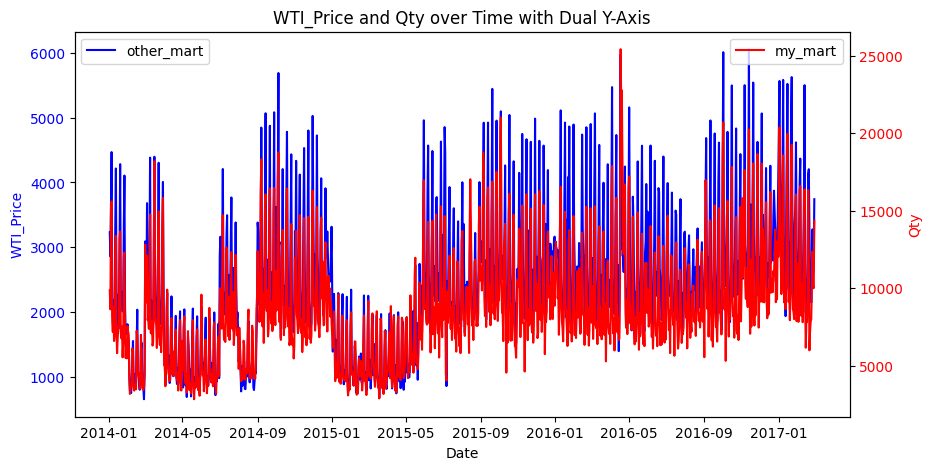

In [ ]:
#비교매장 대상매장 수요량 대조
# 첫 번째 y축 그래프 (왼쪽)
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.lineplot(data=total_1, x='Date', y='Qty', ax=ax1, color="b", label="other_mart")
ax1.set_ylabel('WTI_Price', color="b")
ax1.tick_params(axis='y', labelcolor="b")

# 두 번째 y축 그래프 (오른쪽)
ax2 = ax1.twinx()
sns.lineplot(data=total, x='Date', y='Qty', ax=ax2, color="r", label="my_mart")
ax2.set_ylabel('Qty', color="r")
ax2.tick_params(axis='y', labelcolor="r")

# 제목과 표시
plt.title('WTI_Price and Qty over Time with Dual Y-Axis')
plt.show()

In [ ]:
#이상치 인덱스 조회
print(total.loc[total['Qty'].argmax()])
print(total_1.loc[total_1['Qty'].argmax()])

Date             2016-04-17 00:00:00
CustomerCount                 5242.0
Qty                          25413.0
WTI_Price                      39.96
day                                6
month                              4
oil_range                      31~40
Name: 836, dtype: object
Date             2016-11-13 00:00:00
CustomerCount                 1805.0
Qty                           6056.0
WTI_Price                  43.323333
day                                5
month                             11
oil_range                      41~50
Name: 1045, dtype: object


#####2) 대상 매장(44), Milk 판매량과 휘발유 가격 추이 비교

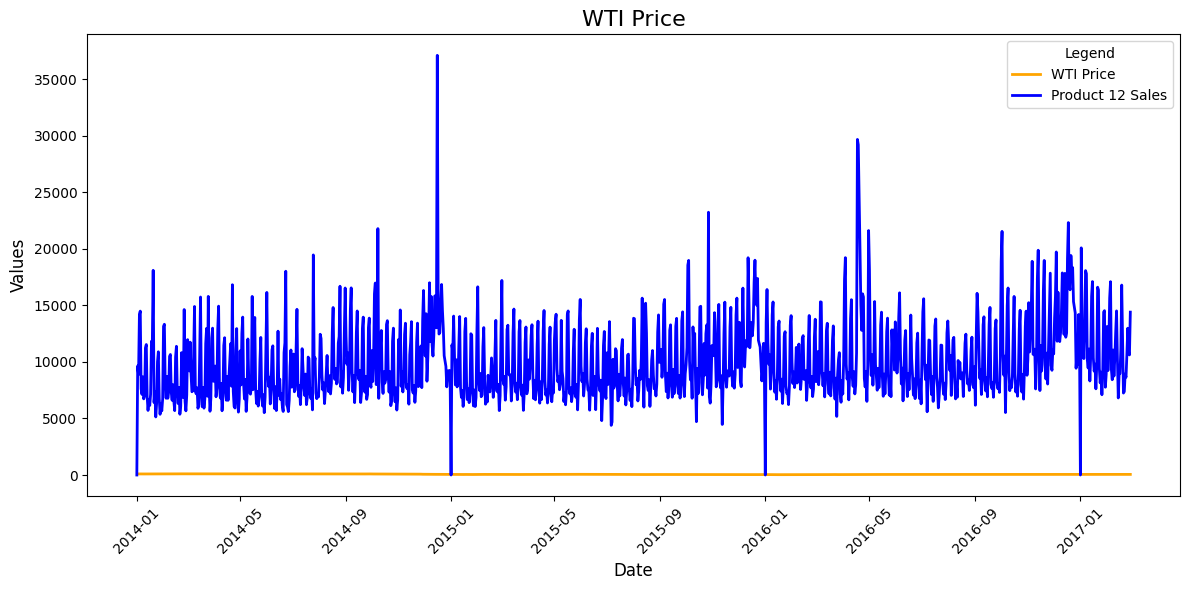

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(sales_12['Date'], sales_12['WTI_Price'], label='WTI Price', color='orange', linewidth=2)
plt.plot(sales_12['Date'], sales_12['Qty'], label='Product 12 Sales', color='blue', linewidth=2)
plt.title('WTI Price', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Legend')
plt.tight_layout()
plt.show()

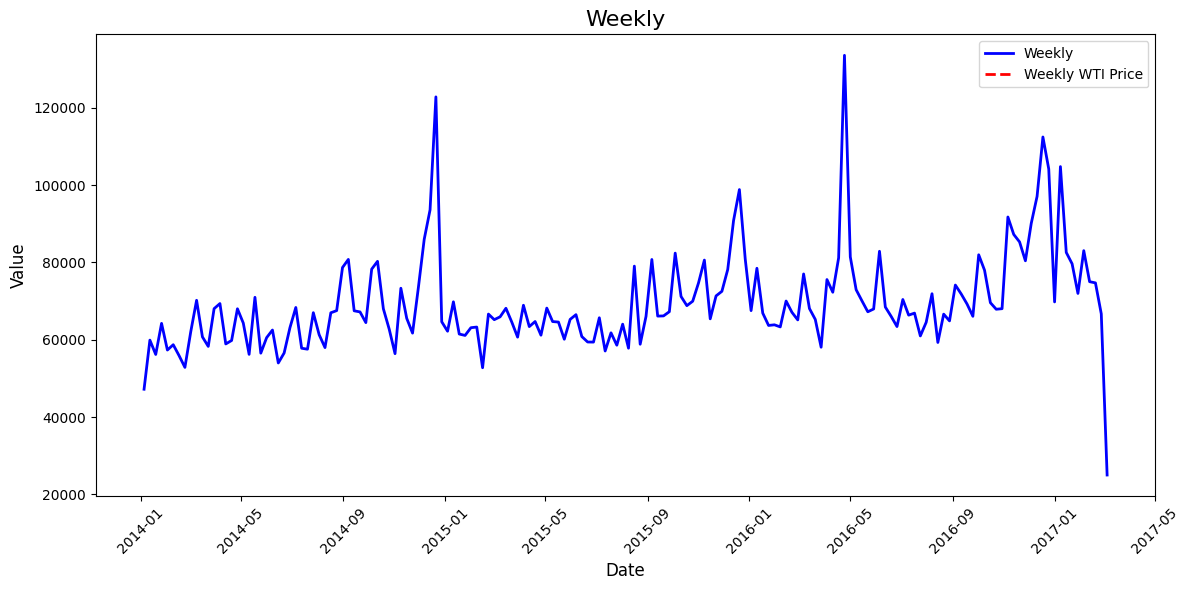

In [ ]:
sales_12_oil_weekly = pd.merge(sales_12_weekly, oil_price, on='Date', how='left')
plt.figure(figsize=(12, 6))
plt.plot(sales_12_oil_weekly['Date'], sales_12_oil_weekly['Qty'], label='Weekly', color='blue', linewidth=2)
plt.plot(sales_12_oil_weekly['Date'], sales_12_oil_weekly['WTI_Price'], label='Weekly WTI Price', color='red', linestyle='--', linewidth=2)
plt.title('Weekly', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#####3) 대상 매장(44), Agricultural products 판매량과 휘발유 가격 추이 비교

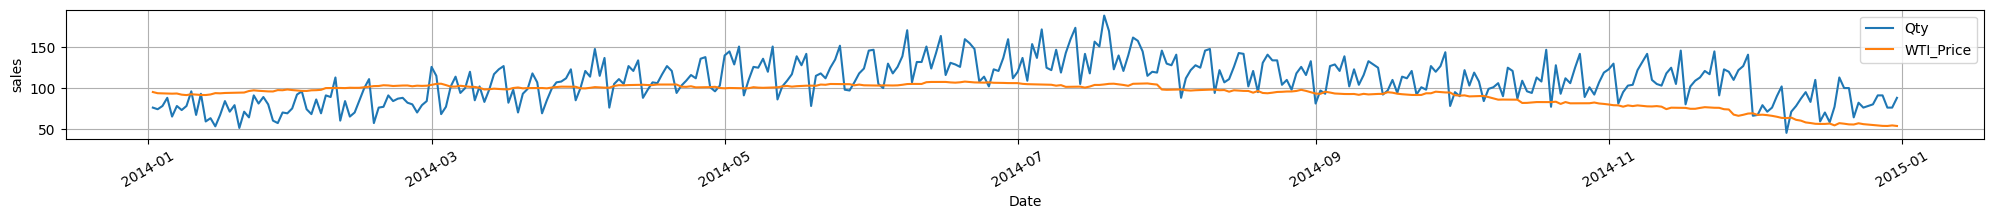

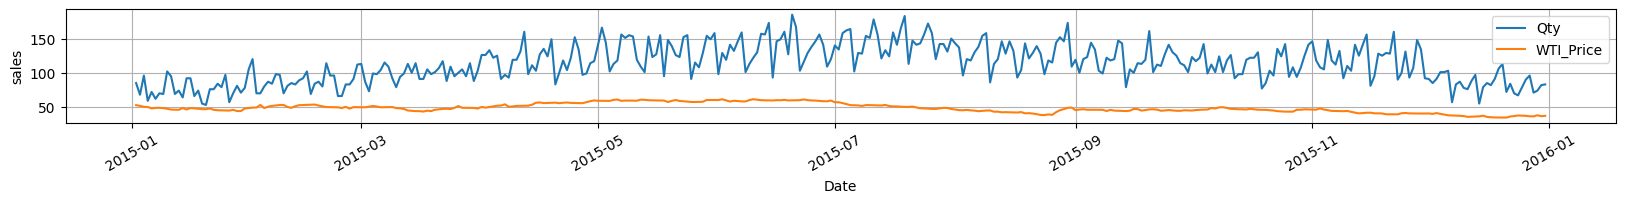

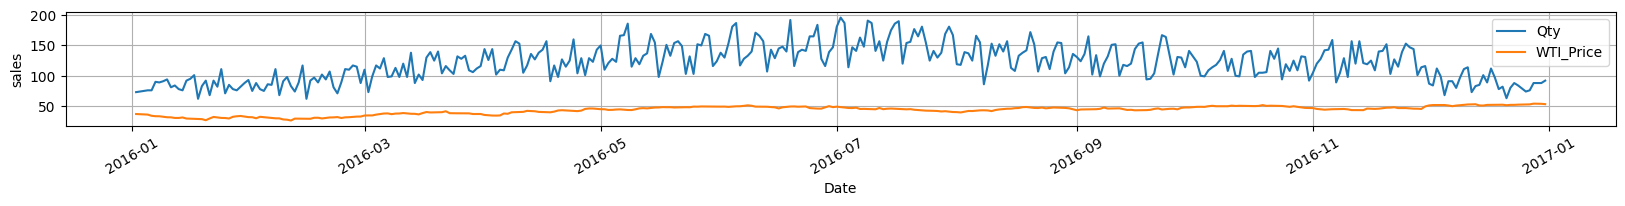

In [ ]:
#연도별 일별 판매량 휘발유와 비교
plt.figure(figsize = (20, 5))
plt.subplot(3,1,1)
plt.tight_layout()
plt.plot(df_2014['Qty'], label='Qty')
plt.plot(df_2014['WTI_Price'], label='WTI_Price')
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()
plt.figure(figsize = (20, 5))
plt.subplot(3,1,2)
plt.plot(df_2015['Qty'], label='Qty')
plt.plot(df_2015['WTI_Price'], label='WTI_Price')
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()
plt.figure(figsize = (20, 5))
plt.subplot(3,1,3)
plt.plot(df_2016['Qty'], label='Qty')
plt.plot(df_2016['WTI_Price'], label='WTI_Price')
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

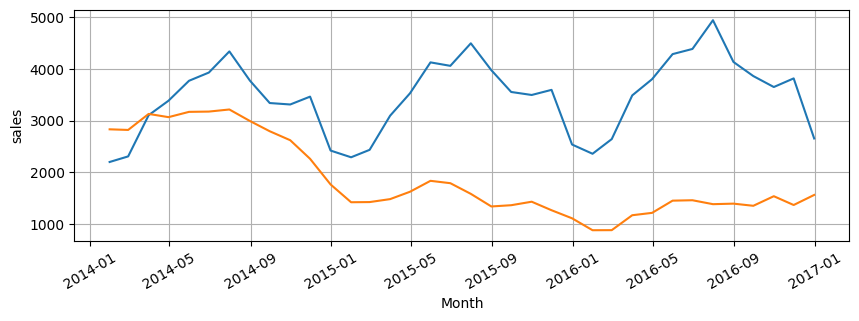

In [ ]:
#월별 판매량
plt.figure(figsize = (10, 3))
qmon = tdf['Qty'].resample('M').sum()
wmon = tdf['WTI_Price'].resample('M').sum()
plt.plot(qmon.index,qmon.values)
plt.plot(wmon.index,wmon.values)
plt.xticks(rotation = 30)
plt.xlabel('Month')
plt.ylabel('sales')
plt.grid()
plt.show()

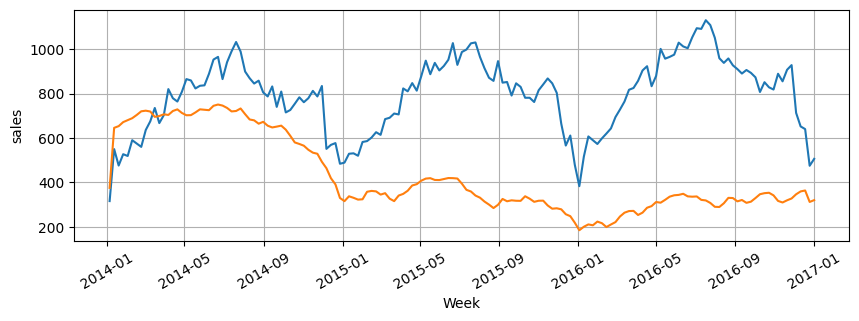

In [ ]:
#주별 판매량
plt.figure(figsize = (10, 3))
qmon = tdf['Qty'].resample('W').sum()
wmon = tdf['WTI_Price'].resample('W').sum()
plt.plot(qmon.index,qmon.values)
plt.plot(wmon.index,wmon.values)
plt.xticks(rotation = 30)
plt.xlabel('Week')
plt.ylabel('sales')
plt.grid()
plt.show()

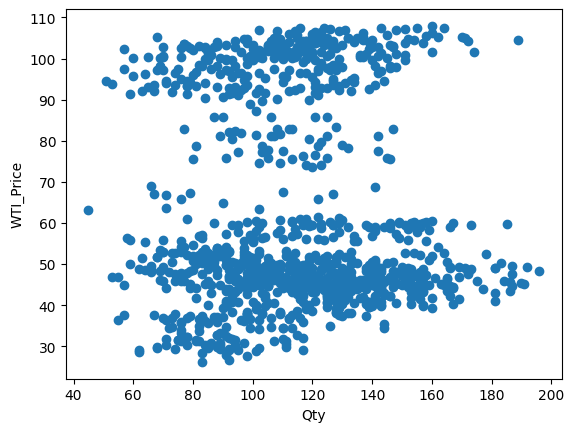

PearsonRResult(statistic=-0.03342481970653827, pvalue=0.2706560741149953)

In [ ]:
import scipy.stats as spst
plt.scatter(tdf['Qty'], tdf['WTI_Price'])
plt.xlabel('Qty')
plt.ylabel('WTI_Price')
plt.show()
spst.pearsonr(tdf['Qty'], tdf['WTI_Price'])

### 4) 방문 고객수와 상품 판매량 추이 비교

#####2) 대상 매장(44), Milk 판매량과 방문 고객수 추이 비교

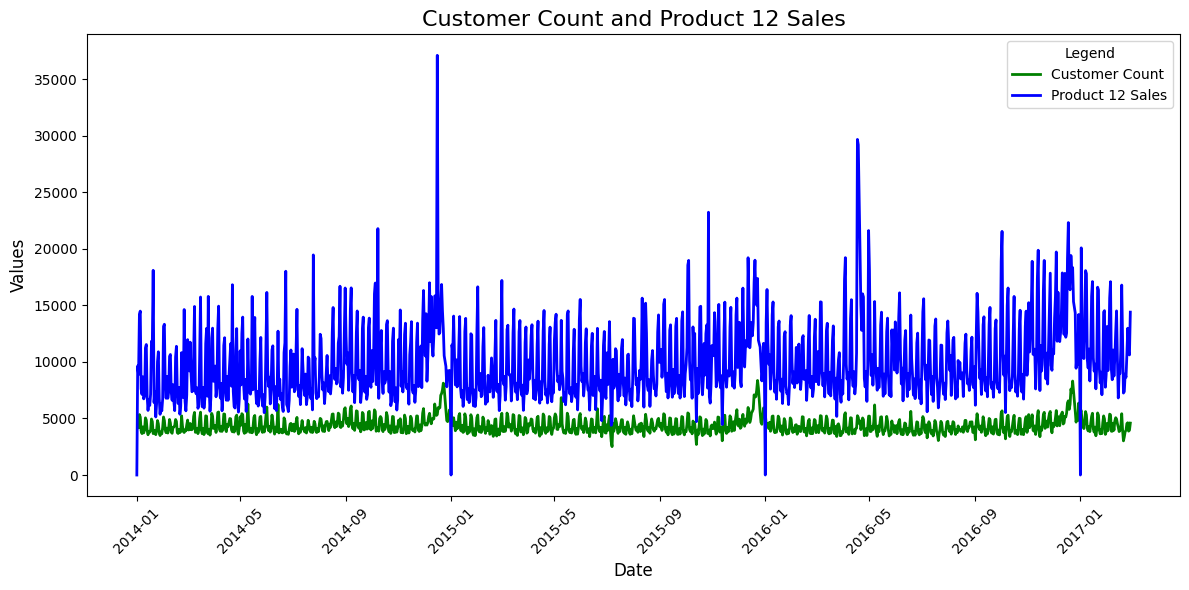

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(sales_12['Date'], sales_12['CustomerCount'], label='Customer Count', color='green', linewidth=2)
plt.plot(sales_12['Date'], sales_12['Qty'], label='Product 12 Sales', color='blue', linewidth=2)
plt.title('Customer Count and Product 12 Sales', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Legend')
plt.tight_layout()
plt.show()

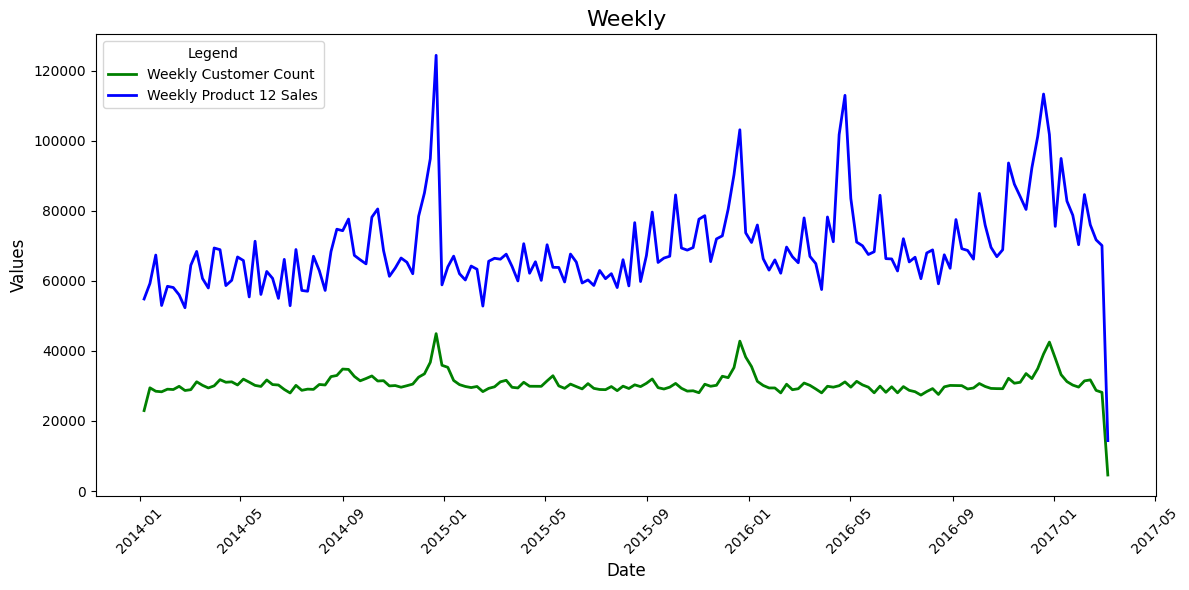

In [ ]:
sales_12['Date'] = pd.to_datetime(sales_12['Date'])
sales_12_weekly = sales_12.resample('W-Mon', on='Date').agg({'CustomerCount': 'sum', 'Qty': 'sum'}).reset_index()
plt.figure(figsize=(12, 6))
plt.plot(sales_12_weekly['Date'], sales_12_weekly['CustomerCount'], label='Weekly Customer Count', color='green', linewidth=2)
plt.plot(sales_12_weekly['Date'], sales_12_weekly['Qty'], label='Weekly Product 12 Sales', color='blue', linewidth=2)
plt.title('Weekly', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Legend')
plt.tight_layout()
plt.show()

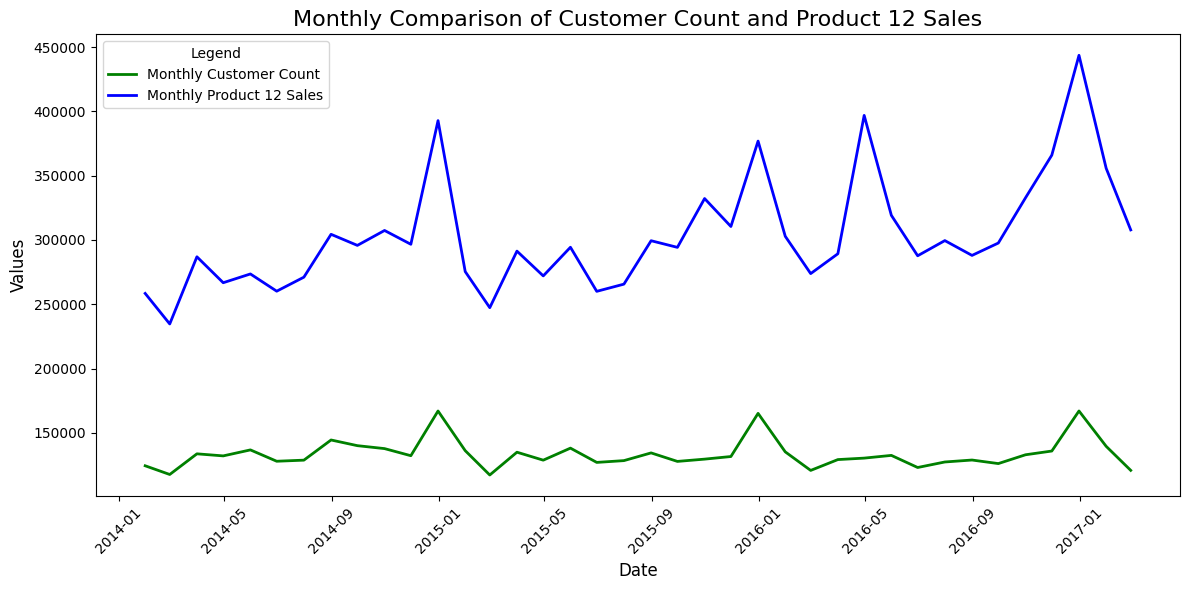

In [ ]:
sales_12_monthly = sales_12.resample('M', on='Date').agg({'CustomerCount': 'sum', 'Qty': 'sum'}).reset_index()
plt.figure(figsize=(12, 6))
plt.plot(sales_12_monthly['Date'], sales_12_monthly['CustomerCount'], label='Monthly Customer Count', color='green', linewidth=2)
plt.plot(sales_12_monthly['Date'], sales_12_monthly['Qty'], label='Monthly Product 12 Sales', color='blue', linewidth=2)
plt.title('Monthly Comparison of Customer Count and Product 12 Sales', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Legend')
plt.tight_layout()
plt.show()

#####3) 대상 매장(44), Agricultural products 판매량과 방문 고객수 추이 비교

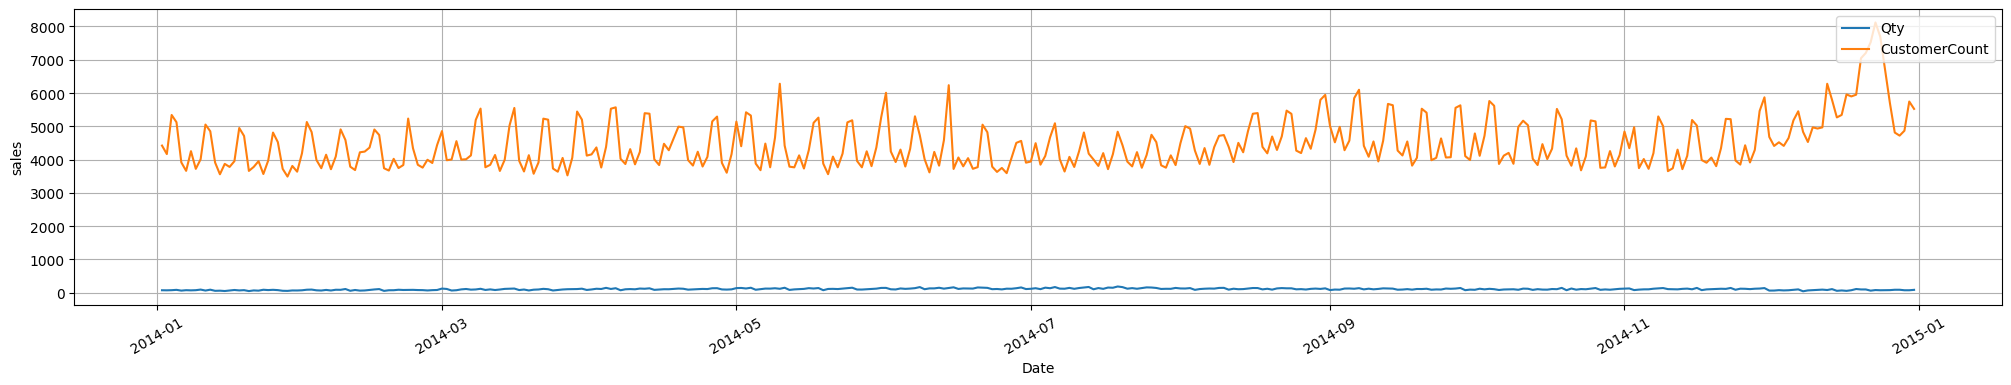

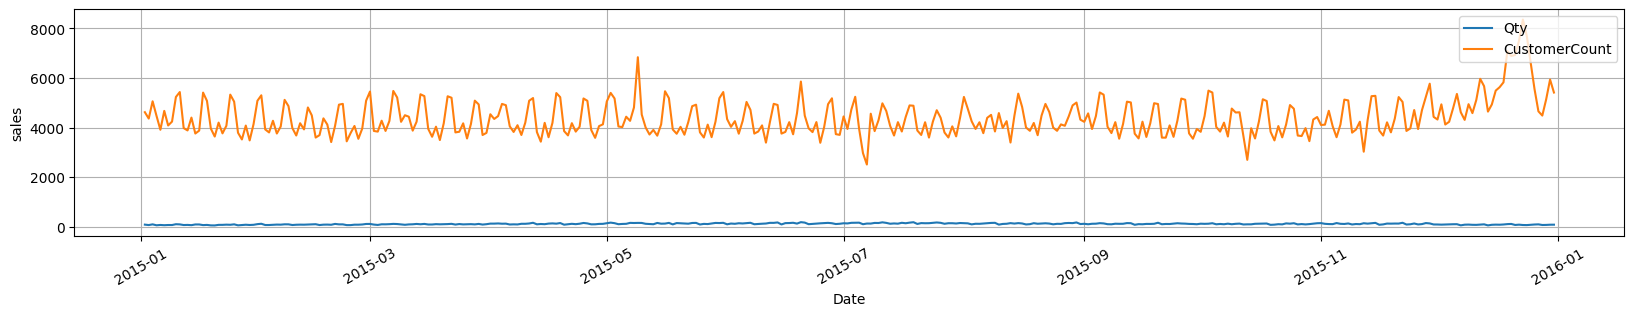

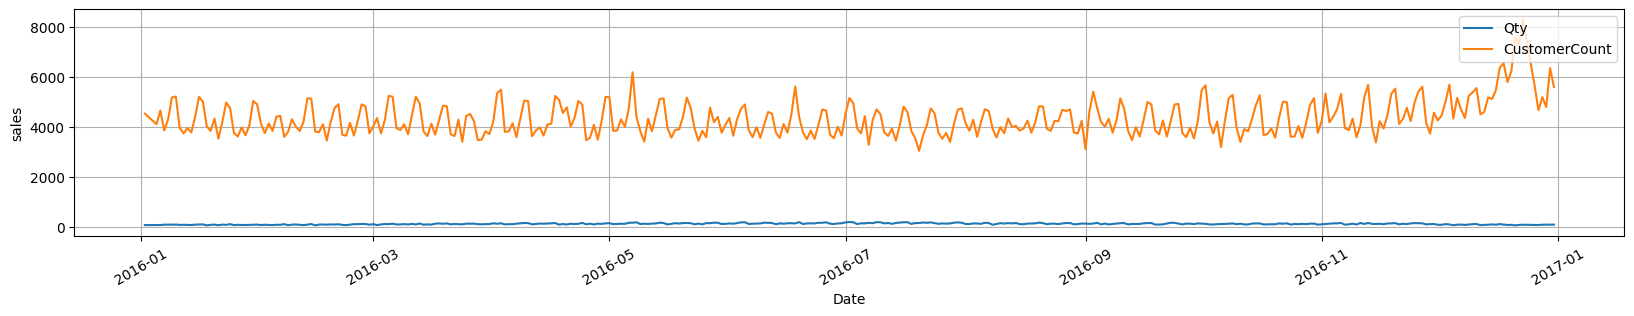

In [ ]:
plt.figure(figsize = (20, 10))
plt.subplot(3,1,1)
plt.tight_layout()
plt.plot(df_2014['Qty'], label='Qty')
plt.plot(df_2014['CustomerCount'], label='CustomerCount')
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()
plt.figure(figsize = (20, 10))
plt.subplot(3,1,2)
plt.plot(df_2015['Qty'], label='Qty')
plt.plot(df_2015['CustomerCount'], label='CustomerCount')
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()
plt.figure(figsize = (20, 10))
plt.subplot(3,1,3)
plt.plot(df_2016['Qty'], label='Qty')
plt.plot(df_2016['CustomerCount'], label='CustomerCount')
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

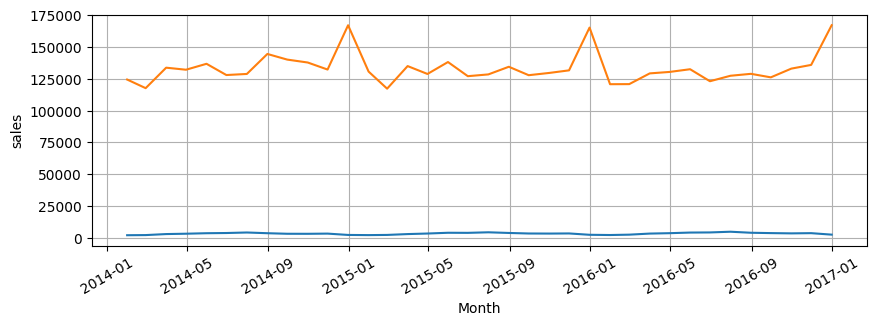

In [ ]:
#월별 판매량
plt.figure(figsize = (10, 3))
qmon = tdf['Qty'].resample('M').sum()
cmon = tdf['CustomerCount'].resample('M').sum()
plt.plot(qmon.index,qmon.values)
plt.plot(cmon.index,cmon.values)
plt.xticks(rotation = 30)
plt.xlabel('Month')
plt.ylabel('sales')
plt.grid()
plt.show()

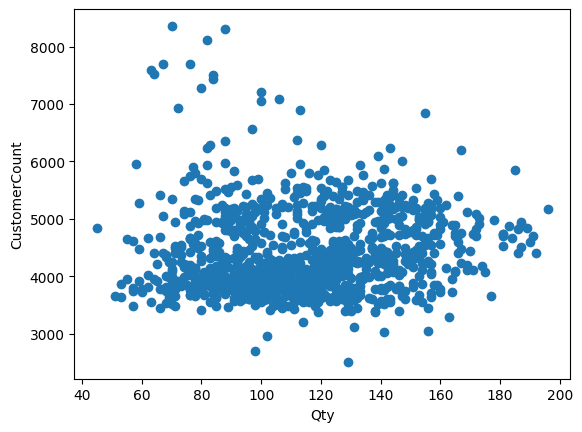

PearsonRResult(statistic=0.08781166258910303, pvalue=0.0037468267366813635)

In [ ]:
plt.scatter(tdf['Qty'], tdf['CustomerCount'])
plt.xlabel('Qty')
plt.ylabel('CustomerCount')
plt.show()
spst.pearsonr(tdf['Qty'], tdf['CustomerCount'])

## **(2) 시계열 패턴 찾아보기2**

* 변화량과 비교해보기

### 1) 대상 매장(44), 대상 상품의 판매량 추이

### 2) 요일별 변화량 비교

#####1) 대상 매장(44), Beverage 요일별 판매량

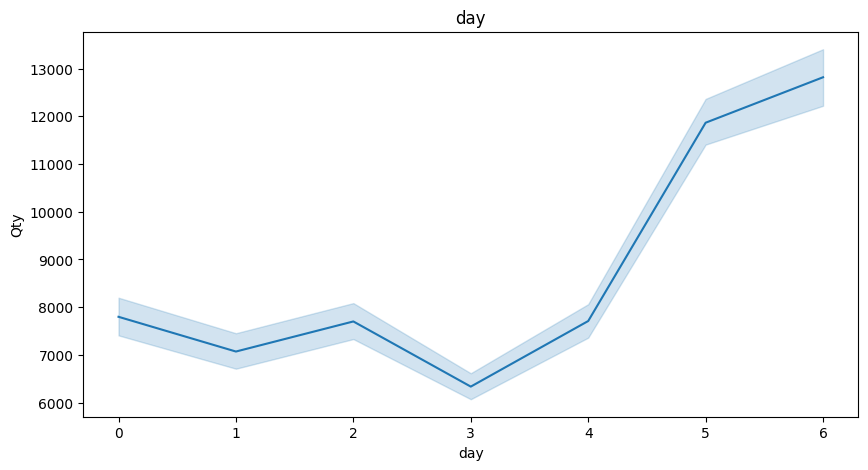

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=total,x='day',y='Qty')
plt.title('day')

plt.show()

#####2) 대상 매장(44), Agricultural Milk 요일별 판매량

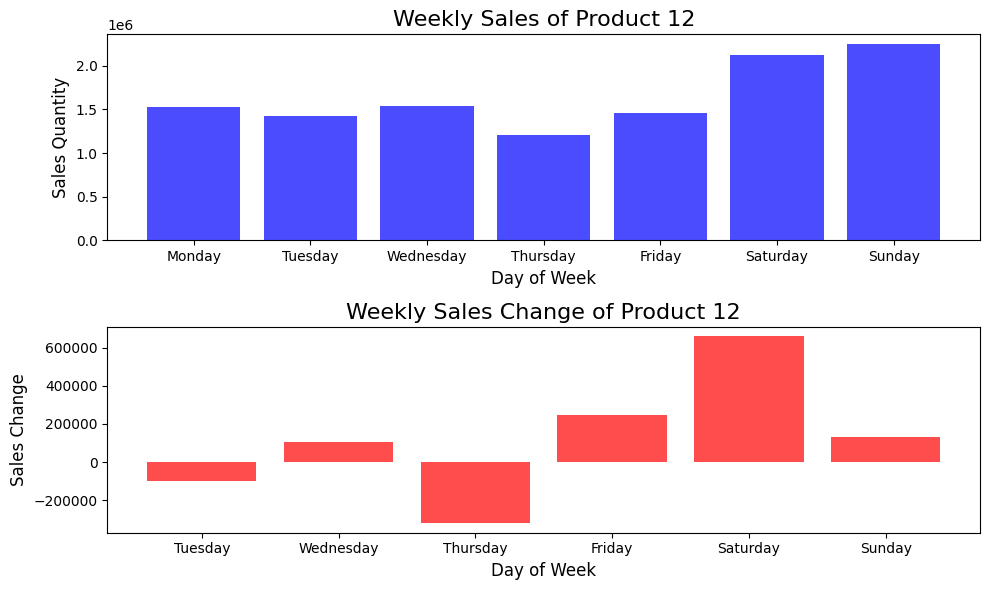

In [ ]:
sales_12['Day_of_Week'] = sales_12['Date'].dt.day_name()
sales_12_weekday = sales_12.groupby('Day_of_Week')['Qty'].sum()
sales_12_weekday = sales_12_weekday[['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']]
sales_12_weekday_change = sales_12_weekday.diff()
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.bar(sales_12_weekday.index, sales_12_weekday, color='b', alpha=0.7)
plt.title('Weekly Sales of Product 12', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Sales Quantity', fontsize=12)
plt.subplot(2, 1, 2)
plt.bar(sales_12_weekday_change.index, sales_12_weekday_change, color='r', alpha=0.7)
plt.title('Weekly Sales Change of Product 12', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Sales Change', fontsize=12)
plt.tight_layout()
plt.show()


#####3) 대상 매장(44), Agricultural products 요일별 판매량

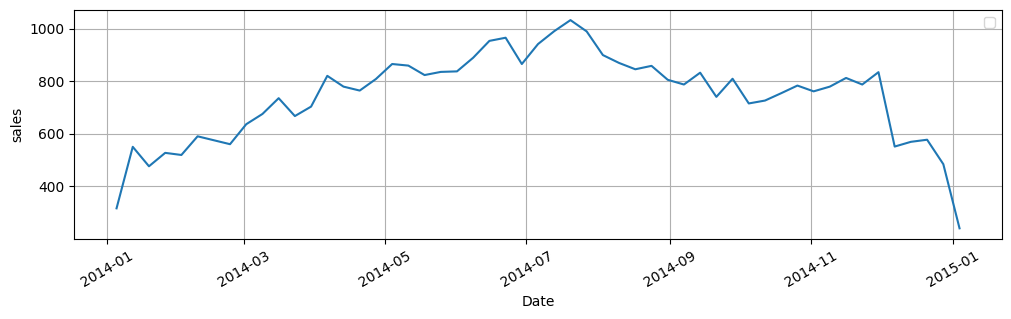

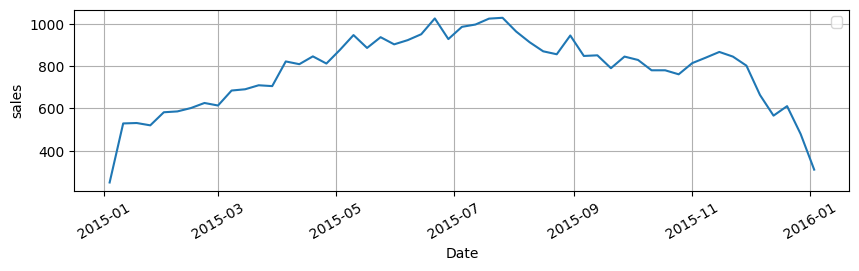

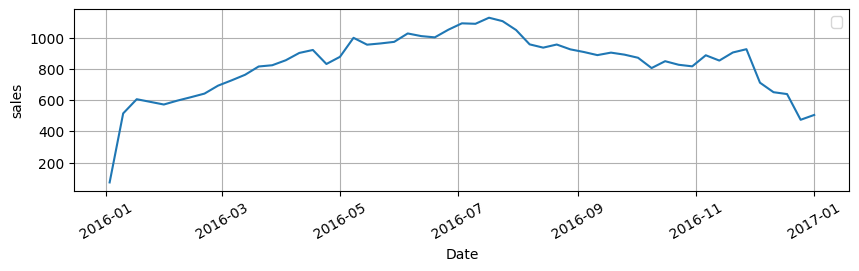

In [ ]:
#연도별 월별 판매량
plt.figure(figsize = (10, 8))
plt.subplot(3,1,1)
plt.tight_layout()
mon_2014 = df_2014['Qty'].resample('W').sum()
plt.plot(mon_2014.index,mon_2014.values)
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()
plt.figure(figsize = (10, 8))
plt.subplot(3,1,2)
mon_2015 = df_2015['Qty'].resample('W').sum()
plt.plot(mon_2015.index,mon_2015.values)
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()
plt.figure(figsize = (10, 8))
plt.subplot(3,1,3)
mon_2016 = df_2016['Qty'].resample('W').sum()
plt.plot(mon_2016.index,mon_2016.values)
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('sales')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

Weekday_name
Friday       18922.0
Monday       14158.0
Saturday     20047.0
Sunday       20956.0
Thursday     17597.0
Tuesday      16359.0
Wednesday    16557.0
Name: Qty, dtype: float64


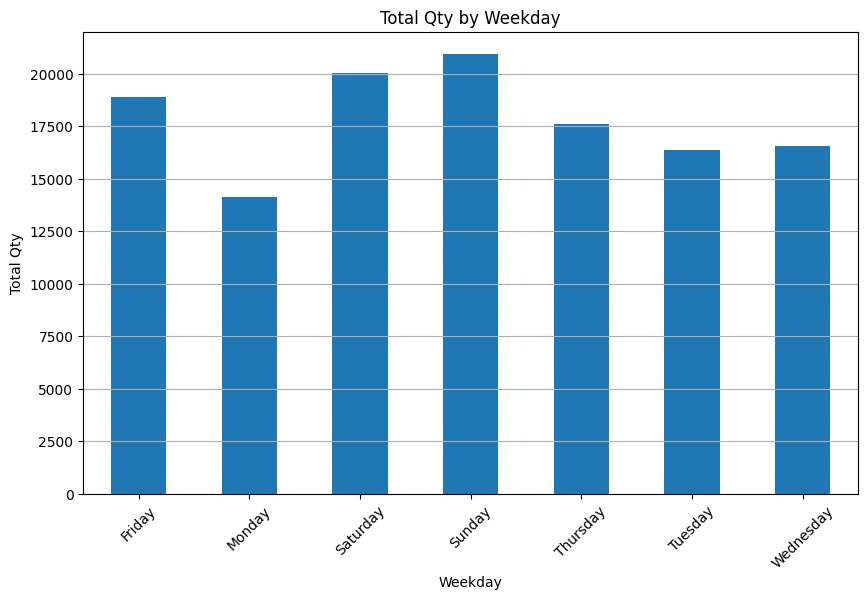

In [ ]:
wn_df = tdf.copy()
wn_df['Weekday'] = wn_df.index.dayofweek
wn_df['Weekday_name'] = wn_df.index.day_name()

weekday_qty = wn_df.groupby('Weekday_name')['Qty'].sum()
print(weekday_qty)

plt.figure(figsize=(10, 6))
weekday_qty.plot(kind='bar')  # 막대 그래프
plt.xlabel('Weekday')
plt.ylabel('Total Qty')
plt.title('Total Qty by Weekday')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### 3) 시계열 데이터 분해

In [ ]:
def decomp_plot(Product_ID, sdate, edate, period ) :

    # 시계열 데이터 분해
    temp = sales.loc[(sales['Store_ID'] == 44) & (sales['Product_ID'] == Product_ID) & (sales['Date'].between(sdate, edate))]
    decomp = sm.tsa.seasonal_decompose(temp['Qty'], model = 'additive', period = period)

    # 시계열 분해 결과를 받아서 데이터프레임으로 저장
    result = pd.DataFrame({'observed':decomp.observed, 'trend':decomp.trend, 'seasonal':decomp.seasonal, 'residual':decomp.resid})

    # 4개의 그래프로 나눠서 그리기
    plt.figure(figsize=(15, 8))

    plt.subplot(4,1,1)
    plt.plot(result['observed'])
    plt.ylabel('observed')

    plt.subplot(4,1,2)
    plt.plot(result['trend'])
    plt.ylabel('trend')

    plt.subplot(4,1,3)
    plt.plot(result['seasonal'])
    plt.ylabel('seasonal')

    plt.subplot(4,1,4)
    plt.plot(result['residual'])
    plt.ylabel('residual')
    plt.show()

    return result

#####1) 대상 매장(44), Beverage 시계열 데이터 분해

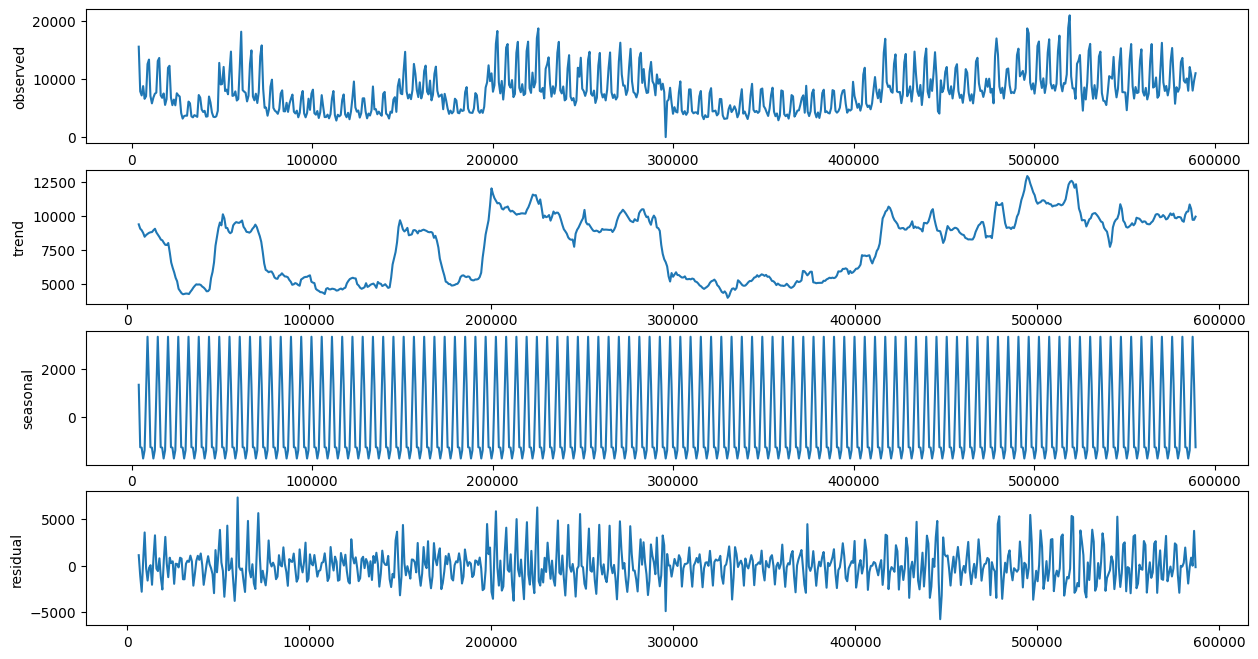

,observed,trend,seasonal,residual
3889,15606.0,NaN,1338.950874,NaN
4700,7900.0,NaN,-1242.077138,NaN
5511,7188.0,NaN,-1257.428678,NaN
6322,8800.0,9392.857143,-1707.058101,1114.200958
7133,6606.0,9075.285714,-1367.284176,-1102.001538
...,...,...,...,...
586189,12093.0,9726.428571,-1367.284176,3733.855604
587000,10697.0,9958.714286,911.488362,-173.202648
587811,8026.0,NaN,3323.408857,NaN
588622,9749.0,NaN,1338.950874,NaN


In [ ]:
decomp_plot(Product_ID=3, sdate='2014-01-05', edate='2015-12-30', period=7)

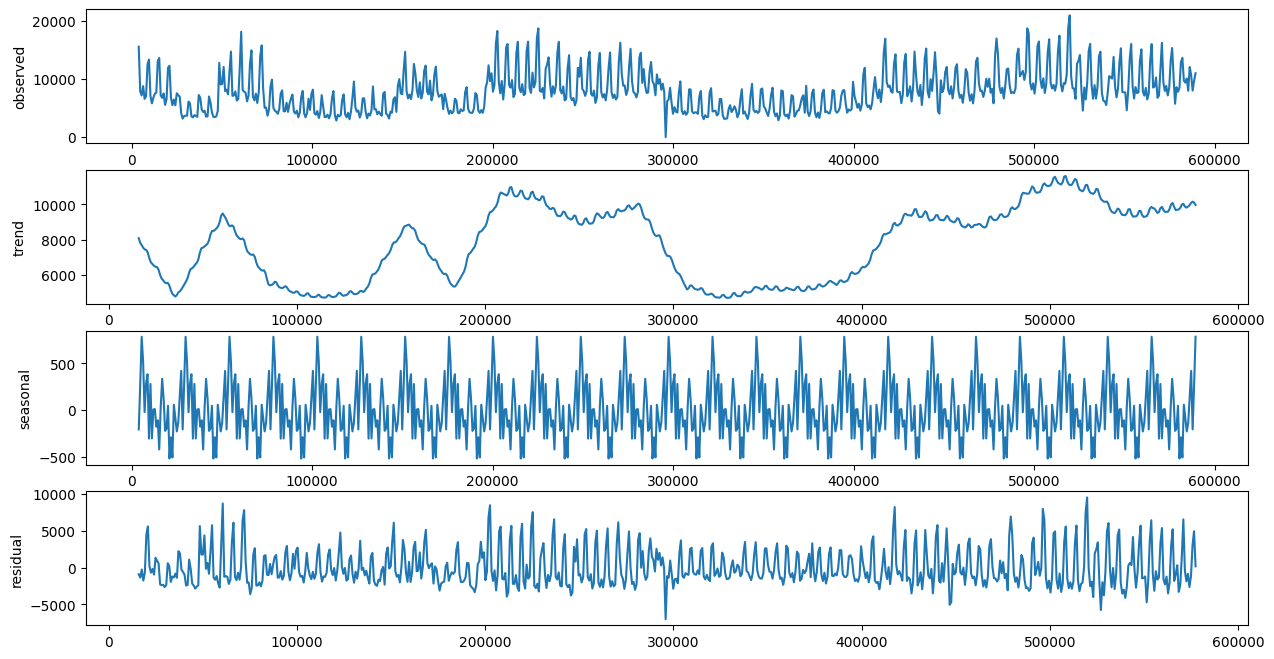

,observed,trend,seasonal,residual
3889,15606.0,NaN,-204.316469,NaN
4700,7900.0,NaN,268.827733,NaN
5511,7188.0,NaN,784.015415,NaN
6322,8800.0,NaN,515.152371,NaN
7133,6606.0,NaN,-20.665745,NaN
...,...,...,...,...
586189,12093.0,NaN,136.827733,NaN
587000,10697.0,NaN,420.132806,NaN
587811,8026.0,NaN,-204.316469,NaN
588622,9749.0,NaN,268.827733,NaN


In [ ]:
decomp_plot(Product_ID=3, sdate='2014-01-05', edate='2015-12-30', period=30)

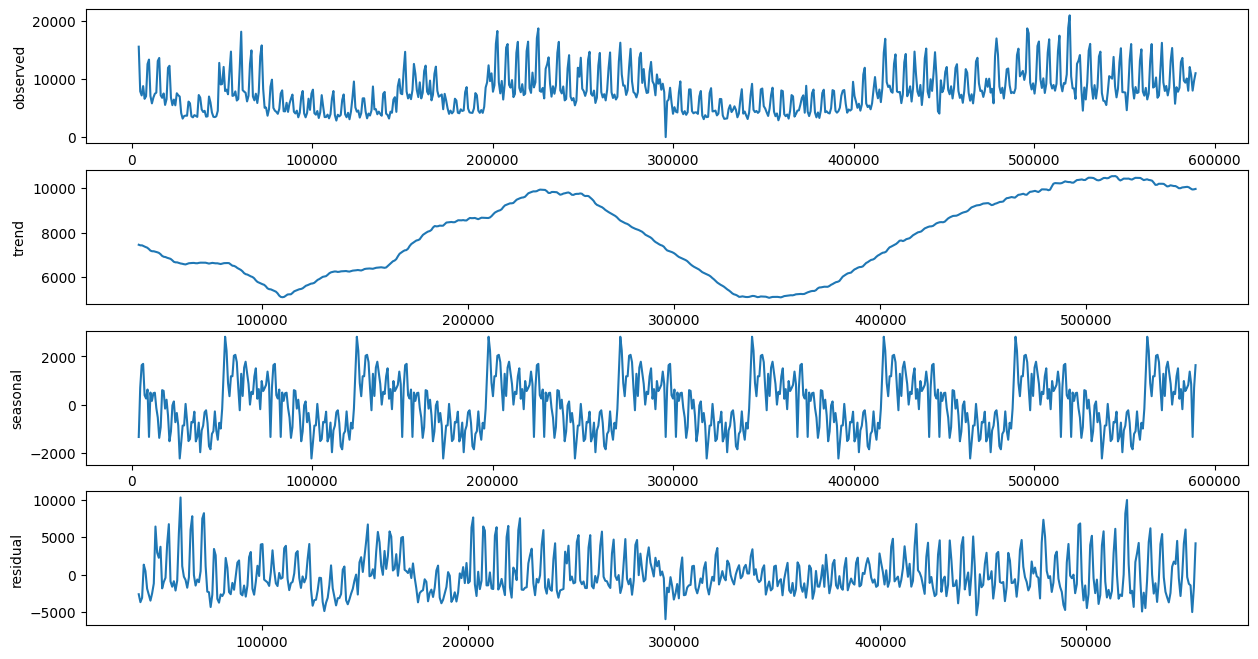

,observed,trend,seasonal,residual
3889,15606.0,NaN,-1345.262632,NaN
4700,7900.0,NaN,698.934987,NaN
5511,7188.0,NaN,1634.727844,NaN
6322,8800.0,NaN,1688.906415,NaN
7133,6606.0,NaN,388.212765,NaN
...,...,...,...,...
586189,12093.0,NaN,1367.931019,NaN
587000,10697.0,NaN,847.339749,NaN
587811,8026.0,NaN,-1345.262632,NaN
588622,9749.0,NaN,698.934987,NaN


In [ ]:
decomp_plot(Product_ID=3, sdate='2014-01-05', edate='2015-12-30', period=90)

#####2) 대상 매장(44), Milk 요일별 판매량

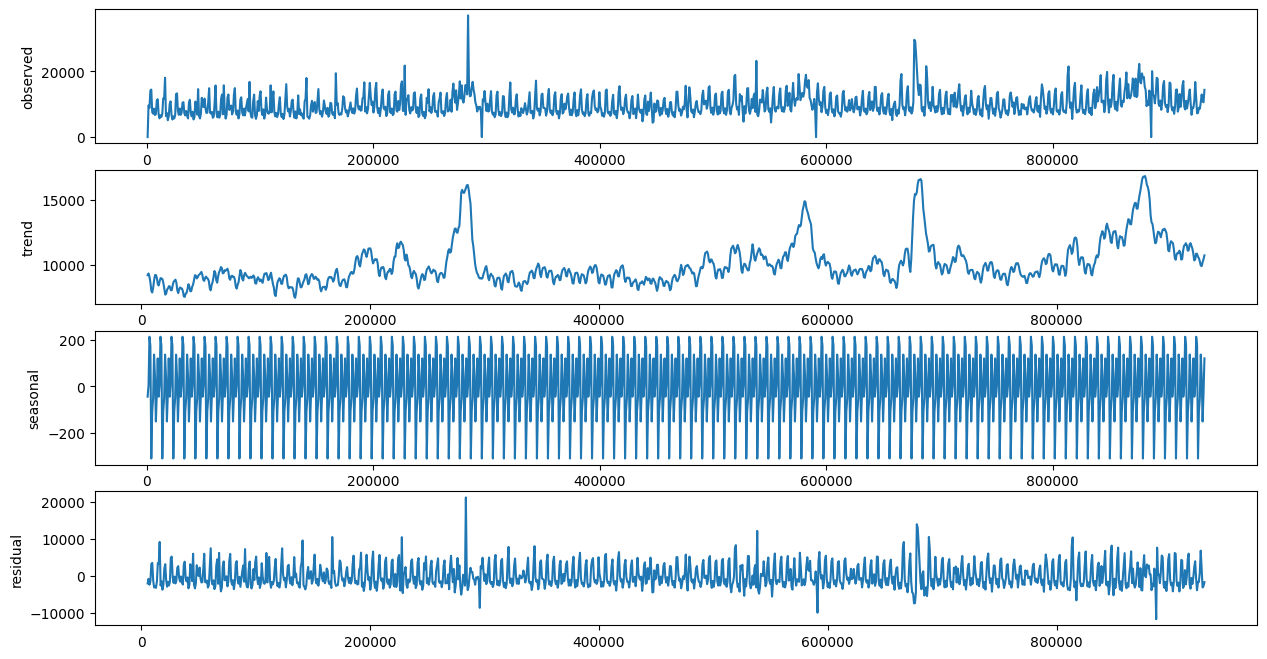

In [ ]:
decomp_result = decomp_plot(Product_ID=12, sdate='2014-01-01', edate='2017-12-31', period=12)

#####3) 대상 매장(44), Agricultural products 요일별 판매량

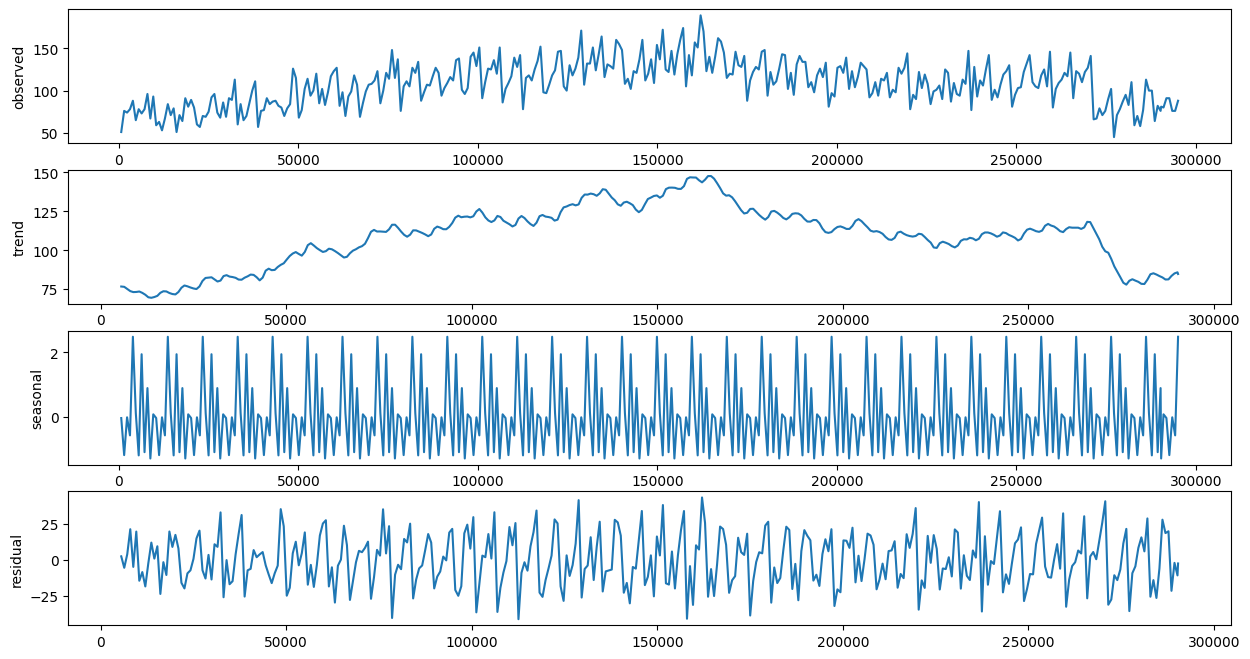

,observed,trend,seasonal,residual
658,51.0,NaN,-0.047585,NaN
1469,76.0,NaN,-1.204195,NaN
2280,74.0,NaN,-0.024597,NaN
3091,78.0,NaN,-0.587815,NaN
3902,88.0,NaN,2.489771,NaN
...,...,...,...,...
291808,91.0,NaN,-0.047585,NaN
292619,91.0,NaN,-1.204195,NaN
293430,76.0,NaN,-0.024597,NaN
294241,76.0,NaN,-0.587815,NaN


In [ ]:
decomp_plot(42, sdate='2014-01-01', edate='2014-12-31', period=12)


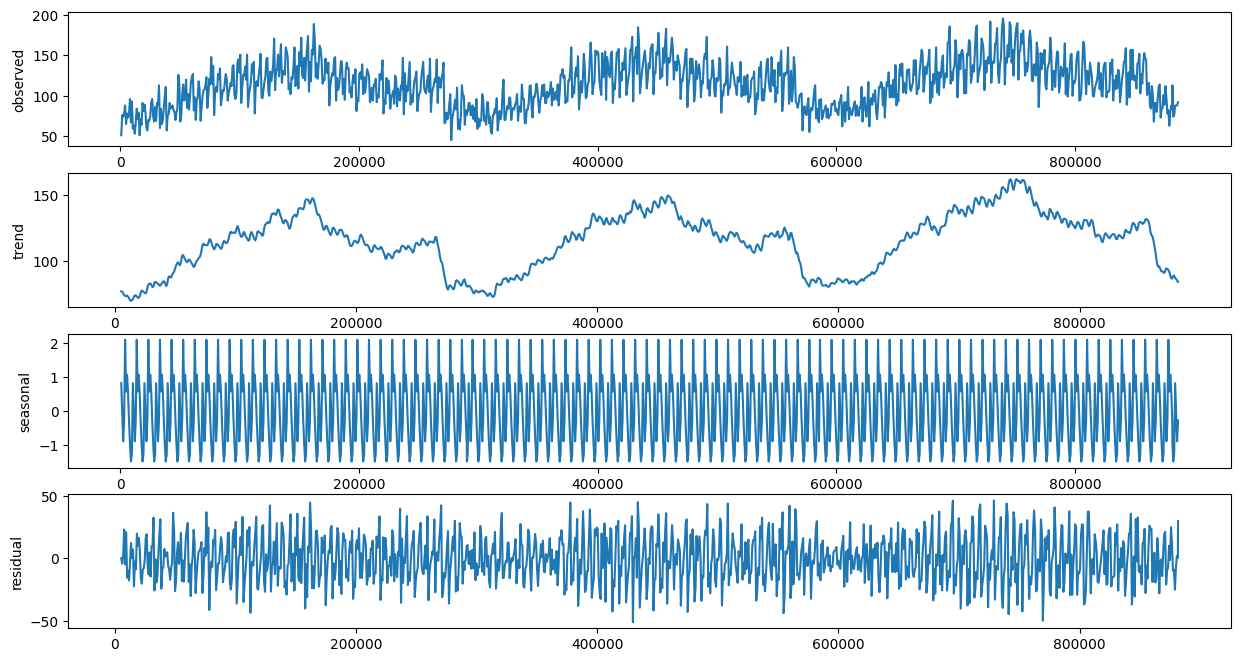

,observed,trend,seasonal,residual
658,51.0,NaN,0.824346,NaN
1469,76.0,NaN,-0.005746,NaN
2280,74.0,NaN,-0.893246,NaN
3091,78.0,NaN,-0.281672,NaN
3902,88.0,NaN,2.107217,NaN
...,...,...,...,...
883029,76.0,NaN,-1.264543,NaN
883840,88.0,NaN,0.824346,NaN
884651,88.0,NaN,-0.005746,NaN
885462,88.0,NaN,-0.893246,NaN


In [ ]:
decomp_plot(42, sdate='2014-01-01', edate='2016-12-31', period=12)

### 4) 그 외 패턴 찾아보기

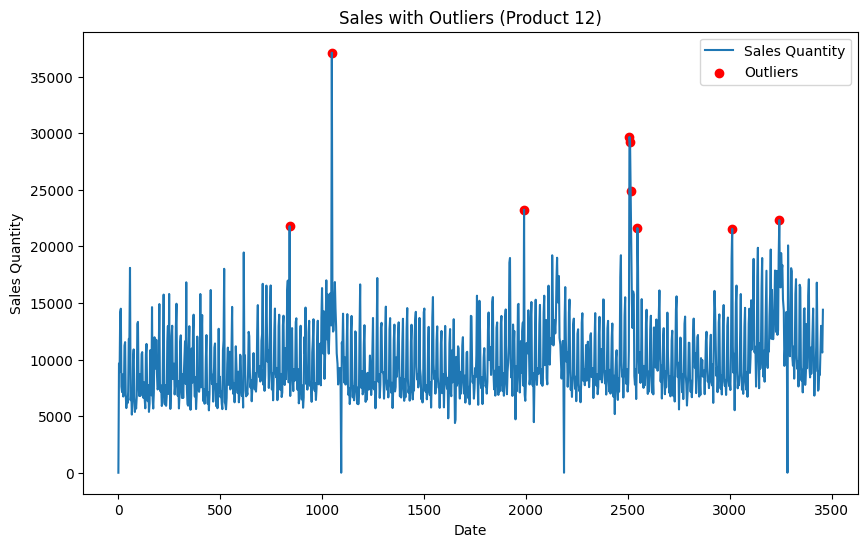

In [ ]:
from scipy import stats

# Z-점수 계산
z_scores = stats.zscore(sales_12['Qty'])

# 이상치 탐지 (예: Z-점수가 3보다 크거나 작은 값)
outliers = sales_12.iloc[np.where(np.abs(z_scores) > 3)]

# 이상치 시각화
plt.figure(figsize=(10, 6))
plt.plot(sales_12['Qty'], label='Sales Quantity')
plt.scatter(outliers.index, outliers['Qty'], color='red', label='Outliers')
plt.title('Sales with Outliers (Product 12)')
plt.xlabel('Date')
plt.ylabel('Sales Quantity')
plt.legend()
plt.show()

In [ ]:
outlier_dates = outliers['Date']
print("Outlier Dates:")
print(outlier_dates)

Outlier Dates:
841    2014-10-08
1048   2014-12-16
1991   2015-10-27
2508   2016-04-17
2511   2016-04-18
2514   2016-04-19
2547   2016-04-30
3012   2016-10-02
3243   2016-12-18
Name: Date, dtype: datetime64[ns]


# **3.패턴 정리하기**

* 다양한 탐색을 통해 찾은 시계열 패턴을 적어 봅시다.

#### 1) 대상 매장(44), Beverage 판매량 추이 정리

- 음료수는 여름이 시작되는 6월붙 ㅓ수요가 점점 증가하기 시작하고 10월이후에는 연말 파티 모임 행사등등으로 수요량이 정점을 찍는것으로 생각이 됨
- 2014-2015 기점으로 유가가 급하락하는 이유는 미국의 셰일혁명으로인해 석유가 대량증산이 되어 세계적으로 유가가 하락한 것으로 생각이 됨 단순 유가와 수요그래프를 보고 관련이있다고 파악되지는 않음

- 목요일 기점으로 음료의 수요량이 폭발적으로 증가가됨 일이 마무리되고 주말에 모임등으로 인해 음료의 수요가 매우 늘어나는 것 으로 확인이 됨

#### 2) 대상 매장(44), Milk 판매량 추이 정리

- 매년 1월 우유 판매량이 급증한다.
- 2016년 6월에 판매량이 급증하는 시기가 있다.
- 주말 판매량이 가장 많다.(토, 일)
- 판매량의 변화량이 수요일에서 목요일로 넘어갈때 가장 많이 줄어든다. 금요일에서 토요일로 넘어갈때 가장 많이 늘어난다.
- (수요일에서 목요일 넘어갈때의 재고 발주량을 줄이고, 금요일에서 주말 넘어갈때 재고 발주량을 늘린다?)
- 특정 구간에서 우유 판매량과 냉동식품 판매량의 흐름이 같이 증가하는 구간이 존재한다.
- 해마다 존재하는 특정일(특정 이벤트 확인) 에 이상치가 존재한다. (해당 일에 대한 데이터의 처리 여부 결정 필요)
- 유가 데이터와 상품 12(milk)와의 관계에 대한 인사이트 도출의 어려움이 있다.

#### 3) 대상 매장(44), Agricultural products 판매량 추이 정리
 - 3분기(7,8,9월)에 가장 많은 판매량을 확인할 수 있음 특히 8월에 판매량이 높음
 - 대상 상품의 동일 카테고리의 상품별 판매량 추이 육류>계란>해산물>농산물 순으로 판매량이 많음
 - 육류도 7,8,9에 판매량이 높아져 농산물과 약간의 연관성이 있어보임
  
  Pearson=0.30, pvalue=8.129431309633259e-25

- 휘발유 가격과 상품 판매량 추이 비교
휘발유 가격과 상품 판매량 사이의 유의미한 인사이트 도출 하기 어려움

- 방문 고객수와 상품 판매량 추이 비교
4000명 언저리에서 가장 많은 판매량을 보임 7~9월에 판매량이 높은 농산물과 고객 방문률은 상관 없어보임

 사람이 많을 수록 판매량이 많을 것 같은데 그렇지 않은 이유에 대해 추가 조사 필요함

- 월<화<수<목<금<토<일 순으로 판매량이 많음, 평일에 사용할 식료품을 주말에 가서 사오는것으로 예상됨